# Periodic-Branch Trigger-Mode Benchmark: LOO Posterior Probability vs Local Bayes Factor

This notebook compares the two dip-triggering choices available inside the MALCA Bayesian event scorer:

- **LOO posterior probability**: per-point leave-one-out posterior probability that the point belongs to the dip/event component.
- **Local Bayes factor**: per-point local log evidence ratio for the event model relative to the baseline model.

The synthetic population is the same family used by `periodic_branch_simulation_benchmark.ipynb`: noisy, seasonal, multi-camera, imperfect periodic light curves with one-off dips injected into most trials and control light curves in the remainder. The default sample size is **12,000 simulated light curves**, which is 1/10 of the 120,000-light-curve default in the periodic-branch benchmark.

The important design choice here is that each light curve and baseline mode is scored once. The notebook then applies both trigger families, including threshold sweeps, to the same `event_probability` and `log_bf_local` arrays. That keeps the comparison focused on trigger behavior rather than differences in simulation draws or baseline fitting.


## How to Run

By default this notebook runs:

- `N_TRIALS = 12000`
- all four periodic-branch modes: true period, 1% selected-period scatter, 5% selected-period scatter, and masked-GP control
- production thresholds plus threshold sweeps for both trigger families

Useful environment overrides before execution:

- `MALCA_TRIGGER_MODE_N_TRIALS=12000` changes the number of simulated light curves.
- `MALCA_TRIGGER_MODE_WORKERS=8` changes process count.
- `MALCA_TRIGGER_MODE_MODES=phase_template_true_period,phase_template_1pct_period_error` limits baseline modes.
- `MALCA_TRIGGER_MODE_FORCE=1` recomputes cached results.
- `MALCA_TRIGGER_MODE_SMOKE=1` runs a quick 48-light-curve smoke test.

Results are cached under `output/diagnostics/trigger_mode_simulation_benchmark/<RUN_TAG>/`.


In [1]:
from pathlib import Path
import os
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "malca" / "evaluation").is_dir():
            return candidate
    raise RuntimeError(f"Could not find MALCA repository root from {start}")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
print("repo root:", REPO_ROOT)

from malca.evaluation.trigger_mode_simulation_benchmark import (
    DEFAULT_LOGBF_THRESHOLDS,
    DEFAULT_POSTERIOR_PROBABILITY_THRESHOLDS,
    TriggerModeBenchmarkConfig,
    load_trigger_mode_simulation_benchmark,
    plot_trigger_mode_trial_diagnostic,
    run_trigger_mode_simulation_benchmark,
    select_disagreement_trials,
    summarize_trigger_results,
    trigger_profiles,
)
from malca.stv.triggering import posterior_probability_threshold

warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 200)
plt.rcParams["figure.dpi"] = 120


repo root: /home/calder/code/malca


/home/calder/miniforge3/envs/malca/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SMOKE = os.environ.get("MALCA_TRIGGER_MODE_SMOKE", "0") == "1"
N_TRIALS = int(os.environ.get("MALCA_TRIGGER_MODE_N_TRIALS", "48" if SMOKE else "12000"))
WORKERS = int(os.environ.get("MALCA_TRIGGER_MODE_WORKERS", "1" if SMOKE else "8"))
FORCE = os.environ.get("MALCA_TRIGGER_MODE_FORCE", "0") == "1"
RUN_TAG = os.environ.get(
    "MALCA_TRIGGER_MODE_RUN_TAG",
    f"trigger_mode_n{N_TRIALS}_seed20260514" + ("_smoke" if SMOKE else ""),
)
MODE_NAMES = tuple(
    x.strip()
    for x in os.environ.get(
        "MALCA_TRIGGER_MODE_MODES",
        "phase_template_true_period,phase_template_1pct_period_error,phase_template_5pct_period_error,gp_masked_control",
    ).split(",")
    if x.strip()
)
OUTPUT_BASE_DIR = Path(
    os.environ.get(
        "MALCA_TRIGGER_MODE_OUTPUT_DIR",
        str(REPO_ROOT / "output" / "diagnostics" / "trigger_mode_simulation_benchmark"),
    )
)

config = TriggerModeBenchmarkConfig(
    output_base_dir=OUTPUT_BASE_DIR,
    run_tag=RUN_TAG,
    n_trials=N_TRIALS,
    workers=WORKERS,
    force=FORCE,
    show_progress=True,
    mode_names=MODE_NAMES,
    posterior_probability_thresholds=DEFAULT_POSTERIOR_PROBABILITY_THRESHOLDS,
    logbf_thresholds=DEFAULT_LOGBF_THRESHOLDS,
)

print(config)
print("\nTrigger profiles:")
display(pd.DataFrame(trigger_profiles(config)))


TriggerModeBenchmarkConfig(output_base_dir=PosixPath('/home/calder/code/malca/output/diagnostics/trigger_mode_simulation_benchmark'), run_tag='trigger_mode_n12000_seed20260514', n_trials=12000, seed=20260514, workers=8, show_progress=True, force=False, mode_names=('phase_template_true_period', 'phase_template_1pct_period_error', 'phase_template_5pct_period_error', 'gp_masked_control'), control_fraction=0.1, small_dip_fraction=0.5, medium_dip_fraction=0.32, broad_dip_fraction=0.08, logbf_threshold_dip=5.0, significance_threshold=99.99997, posterior_probability_thresholds=(0.9, 0.95, 0.99, 0.999, 0.9999, 0.99999, 0.9999997), logbf_thresholds=(0.0, 1.0, 2.0, 3.0, 5.0, 7.0, 10.0, 15.0, 20.0), p_points=12, mag_points=12, run_min_points=2, run_max_gap_points=5, run_max_gap_days=None, run_min_duration_days=0.0, baseline_s0=0.0005, baseline_w0=0.0031415926535897933, baseline_q=0.7, baseline_jitter=0.006, baseline_sigma_floor=None)

Trigger profiles:


,trigger_profile,trigger_profile_label,trigger_family,trigger_mode,threshold,is_production
0,loo_p_ge_0p9,LOO posterior P(event) >= 0.9,loo_posterior_prob,posterior_prob,0.90000,False
1,loo_p_ge_0p95,LOO posterior P(event) >= 0.95,loo_posterior_prob,posterior_prob,0.95000,False
2,loo_p_ge_0p99,LOO posterior P(event) >= 0.99,loo_posterior_prob,posterior_prob,0.99000,False
3,loo_p_ge_0p999,LOO posterior P(event) >= 0.999,loo_posterior_prob,posterior_prob,0.99900,False
4,loo_p_ge_0p9999,LOO posterior P(event) >= 0.9999,loo_posterior_prob,posterior_prob,0.99990,False
5,loo_p_ge_0p99999,LOO posterior P(event) >= 0.99999,loo_posterior_prob,posterior_prob,0.99999,False
6,loo_p_ge_0p9999997_production,LOO posterior P(event) >= 0.9999997 (production),loo_posterior_prob,posterior_prob,1.00000,True
7,logbf_ge_0,local log BF >= 0,local_logbf,logbf,0.00000,False
8,logbf_ge_1,local log BF >= 1,local_logbf,logbf,1.00000,False
9,logbf_ge_2,local log BF >= 2,local_logbf,logbf,2.00000,False


## Execute or Load Cached Benchmark

This cell generates the synthetic design, scores each simulated light curve under each selected baseline mode, applies the trigger threshold sweeps, and writes parquet/CSV summaries. If the run directory already exists, it loads cached outputs unless `MALCA_TRIGGER_MODE_FORCE=1` is set.


In [3]:
run = run_trigger_mode_simulation_benchmark(config)
results = run.trigger_results.copy()
scores = run.score_results.copy()
plots_dir = run.run_dir / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)

print("run_dir:", run.run_dir)
print("trial design:", run.trial_design.shape)
print("score rows:", scores.shape)
print("trigger rows:", results.shape)
print("production rows:", results[results["is_production"].fillna(False)].shape)


Trigger-mode simulations: 100%|██████████| 48000/48000 [08:34<00:00, 93.29it/s] 
/home/calder/code/malca/malca/evaluation/trigger_mode_simulation_benchmark.py:572: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  observable = has_dip & ok["truth_observable_actual"].fillna(False).astype(bool) if len(ok) else pd.Series(dtype=bool)
/home/calder/code/malca/malca/evaluation/trigger_mode_simulation_benchmark.py:574: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  detected = ok["dip_significant"].fillna(False).astype(bool) if "dip_significant" in ok.columns else pd.

run_dir: /home/calder/code/malca/output/diagnostics/trigger_mode_simulation_benchmark/trigger_mode_n12000_seed20260514
trial design: (12000, 32)
score rows: (48000, 62)
trigger rows: (768000, 84)
production rows: (96000, 84)


## Simulation Population Audit

These plots show whether the run spans the intended input space: periods, periodic amplitudes, injected dip amplitudes and widths, camera offsets, and baseline imperfections. Use this first to catch accidental over-narrowing of the simulated population.


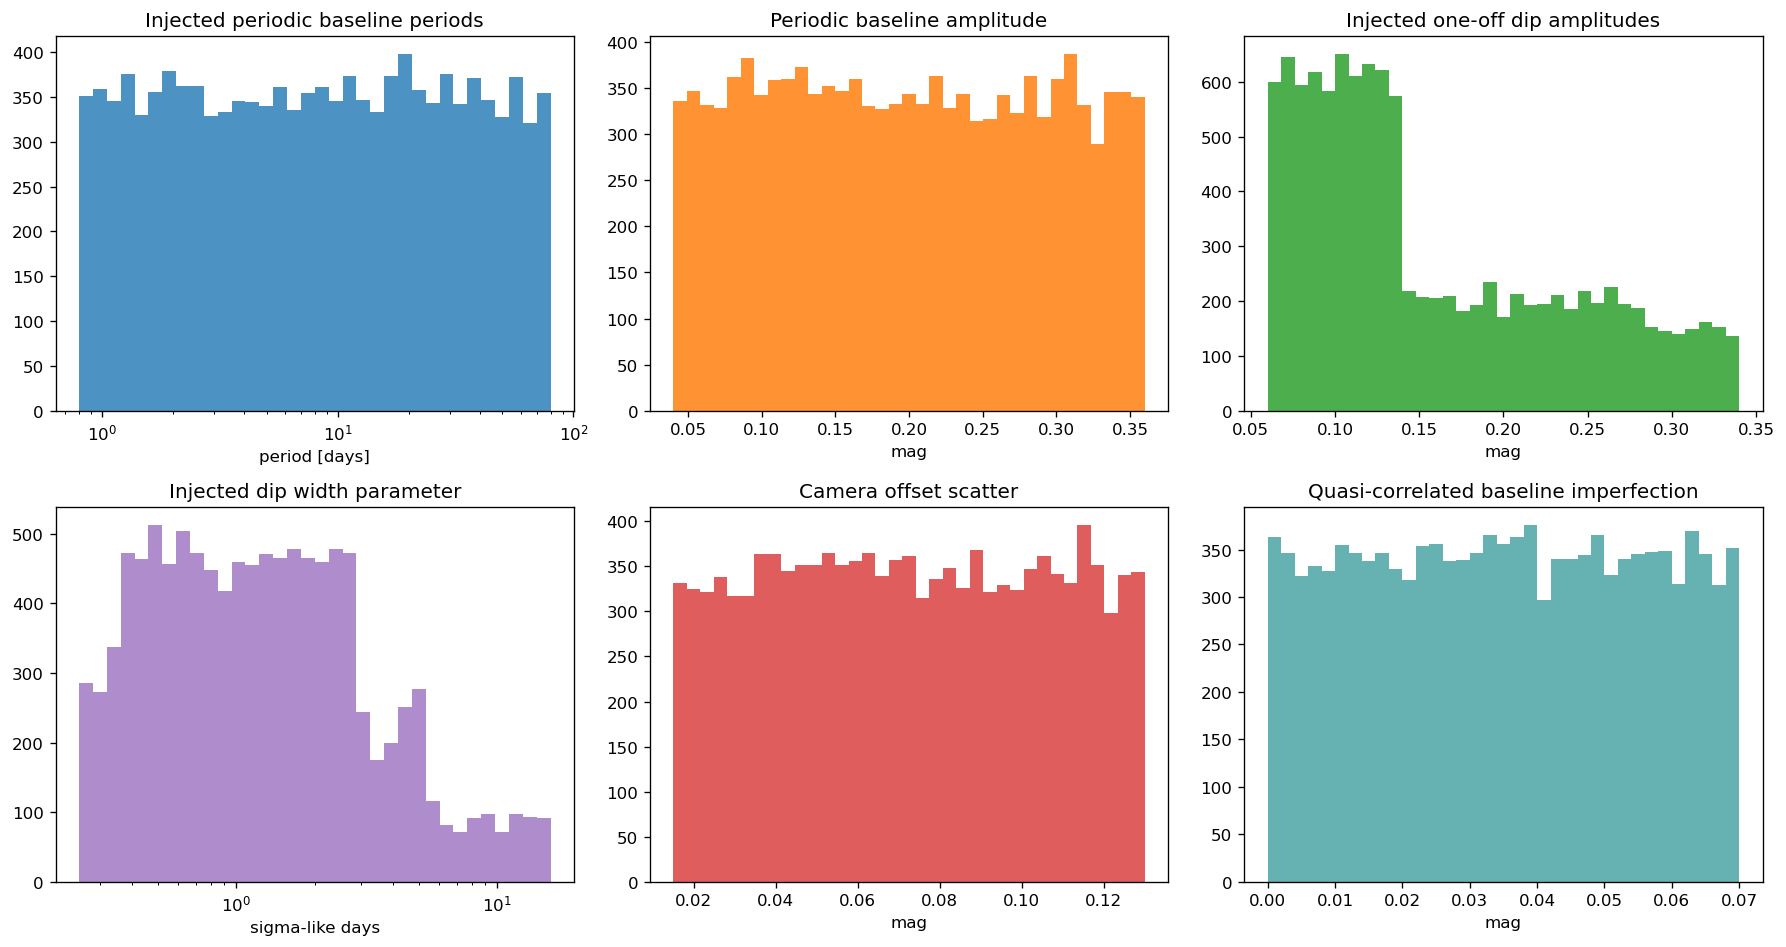

,dip_class,n,fraction
0,small,5934,0.494500
1,medium,3893,0.324417
2,control_none,1192,0.099333
3,broad,981,0.081750


In [4]:
from malca.plotting.lightcurve_publication import finalize_publication_figure
design = run.trial_design.copy()
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()
axes[0].hist(design["period_days"], bins=np.logspace(np.log10(0.8), np.log10(80), 35), color="tab:blue", alpha=0.8)
axes[0].set_xscale("log")
axes[0].set_title("Injected periodic baseline periods")
axes[0].set_xlabel("period [days]")
axes[1].hist(design["periodic_amp_mag"], bins=35, color="tab:orange", alpha=0.85)
axes[1].set_title("Periodic baseline amplitude")
axes[1].set_xlabel("mag")
axes[2].hist(design.loc[design["has_dip"], "dip_amp_mag"], bins=35, color="tab:green", alpha=0.85)
axes[2].set_title("Injected one-off dip amplitudes")
axes[2].set_xlabel("mag")
axes[3].hist(design.loc[design["has_dip"], "dip_sigma_days"], bins=np.logspace(np.log10(0.25), np.log10(16), 35), color="tab:purple", alpha=0.75)
axes[3].set_xscale("log")
axes[3].set_title("Injected dip width parameter")
axes[3].set_xlabel("sigma-like days")
axes[4].hist(design["camera_offset_sigma_mag"], bins=35, color="tab:red", alpha=0.75)
axes[4].set_title("Camera offset scatter")
axes[4].set_xlabel("mag")
axes[5].hist(design["quasi_noise_amp_mag"], bins=35, color="teal", alpha=0.6)
axes[5].set_title("Quasi-correlated baseline imperfection")
axes[5].set_xlabel("mag")
finalize_publication_figure(fig)
fig.savefig(plots_dir / "simulation_population_audit.png")
plt.show()

class_counts = design["dip_class"].value_counts().rename_axis("dip_class").reset_index(name="n")
class_counts["fraction"] = class_counts["n"] / len(design)
display(class_counts)


## Production Threshold Comparison

These are the direct production-threshold results: LOO posterior probability uses the configured `SIGNIFICANCE_THRESHOLD`, and local log BF uses `LOGBF_THRESHOLD_DIP`. Read these as the operational comparison before considering threshold retuning.


In [5]:
production = results[results["is_production"].fillna(False)].copy()
production_summary = run.summary_slices["production_overall"].sort_values(["mode", "trigger_family"])
display(production_summary)

print("Pairwise comparison of production triggers, matched by trial and baseline mode:")
display(run.pairwise_production)


,mode,trigger_family,trigger_profile,threshold,n,n_ok,n_dip,n_observable_dip,n_control,status_error_rate,dip_significant_rate,observable_recall,all_dip_recall,control_false_positive_rate,off_target_detection_rate,precision_by_trial,phase_template_fallback_rate,median_raw_trigger_points,median_event_points,median_trigger_max,median_max_event_probability,median_max_log_bf_local,median_bayes_factor,median_baseline_mae_outside_dip,median_resid_rms_outside_dip,median_amp_recovery_ratio
0,gp_masked_control,local_logbf,logbf_ge_5_production,5.0,12000,11371,10242,7429,1129,0.052417,0.328555,0.075784,0.061902,0.302037,0.269576,0.169700,0.000000,1.0,0.0,5.177651,0.719557,5.177651,0.303676,0.143995,0.184866,1.775236
1,gp_masked_control,loo_posterior_prob,loo_p_ge_0p9999997_production,1.0,12000,11371,10242,7429,1129,0.052417,0.171665,0.021537,0.017965,0.159433,0.155048,0.094262,0.000000,0.0,0.0,0.719557,0.719557,5.177651,0.303676,0.143995,0.184866,1.775236
2,phase_template_1pct_period_error,local_logbf,logbf_ge_5_production,5.0,12000,11638,10481,7643,1157,0.030167,0.137996,0.096036,0.071176,0.071737,0.074134,0.464508,0.000344,0.0,0.0,4.128349,0.328894,4.128349,-1.262110,0.056517,0.102437,1.256317
3,phase_template_1pct_period_error,loo_posterior_prob,loo_p_ge_0p9999997_production,1.0,12000,11638,10481,7643,1157,0.030167,0.002750,0.002486,0.001813,0.003457,0.000859,0.593750,0.000344,0.0,0.0,0.328894,0.328894,4.128349,-1.262110,0.056517,0.102437,1.256317
4,phase_template_5pct_period_error,local_logbf,logbf_ge_5_production,5.0,12000,11649,10497,7661,1152,0.029250,0.112113,0.074664,0.055540,0.074653,0.060684,0.446401,0.000343,0.0,0.0,3.766043,0.285082,3.766043,-1.353647,0.066253,0.114928,1.292528
5,phase_template_5pct_period_error,loo_posterior_prob,loo_p_ge_0p9999997_production,1.0,12000,11649,10497,7661,1152,0.029250,0.001803,0.001044,0.000762,0.001736,0.001048,0.380952,0.000343,0.0,0.0,0.285082,0.285082,3.766043,-1.353647,0.066253,0.114928,1.292528
6,phase_template_true_period,local_logbf,logbf_ge_5_production,5.0,12000,11618,10464,7636,1154,0.031833,0.146927,0.160162,0.117450,0.048527,0.040329,0.719977,0.000344,0.0,0.0,4.080626,0.275689,4.080626,-1.598825,0.037693,0.075908,1.160728
7,phase_template_true_period,loo_posterior_prob,loo_p_ge_0p9999997_production,1.0,12000,11618,10464,7636,1154,0.031833,0.005337,0.005369,0.003918,0.003466,0.001625,0.661290,0.000344,0.0,0.0,0.275689,0.275689,4.080626,-1.598825,0.037693,0.075908,1.160728


Pairwise comparison of production triggers, matched by trial and baseline mode:


,mode,mode_label,n_common,n_observable_dip,n_control,posterior_observable_recall,logbf_observable_recall,both_recovered_rate,posterior_only_recovered_rate,logbf_only_recovered_rate,both_missed_rate,posterior_control_false_positive_rate,logbf_control_false_positive_rate,both_false_positive_rate,posterior_only_false_positive_rate,logbf_only_false_positive_rate,detection_agreement_rate,recovery_agreement_rate_observable,median_event_points_delta_posterior_minus_logbf
0,gp_masked_control,Masked per-camera GP control,11371,7429,1129,0.021537,0.075784,0.021537,0.0,0.054247,0.924216,0.159433,0.302037,0.159433,0.0,0.142604,0.843110,0.945753,0.0
1,phase_template_1pct_period_error,"Phase template, 1% selected-period scatter",11638,7643,1157,0.002486,0.096036,0.002486,0.0,0.093550,0.903964,0.003457,0.071737,0.003457,0.0,0.068280,0.864753,0.906450,0.0
2,phase_template_5pct_period_error,"Phase template, 5% selected-period scatter",11649,7661,1152,0.001044,0.074664,0.001044,0.0,0.073620,0.925336,0.001736,0.074653,0.001736,0.0,0.072917,0.889690,0.926380,0.0
3,phase_template_true_period,"Phase template, true period",11618,7636,1154,0.005369,0.160162,0.005369,0.0,0.154793,0.839838,0.003466,0.048527,0.003466,0.0,0.045061,0.858409,0.845207,0.0


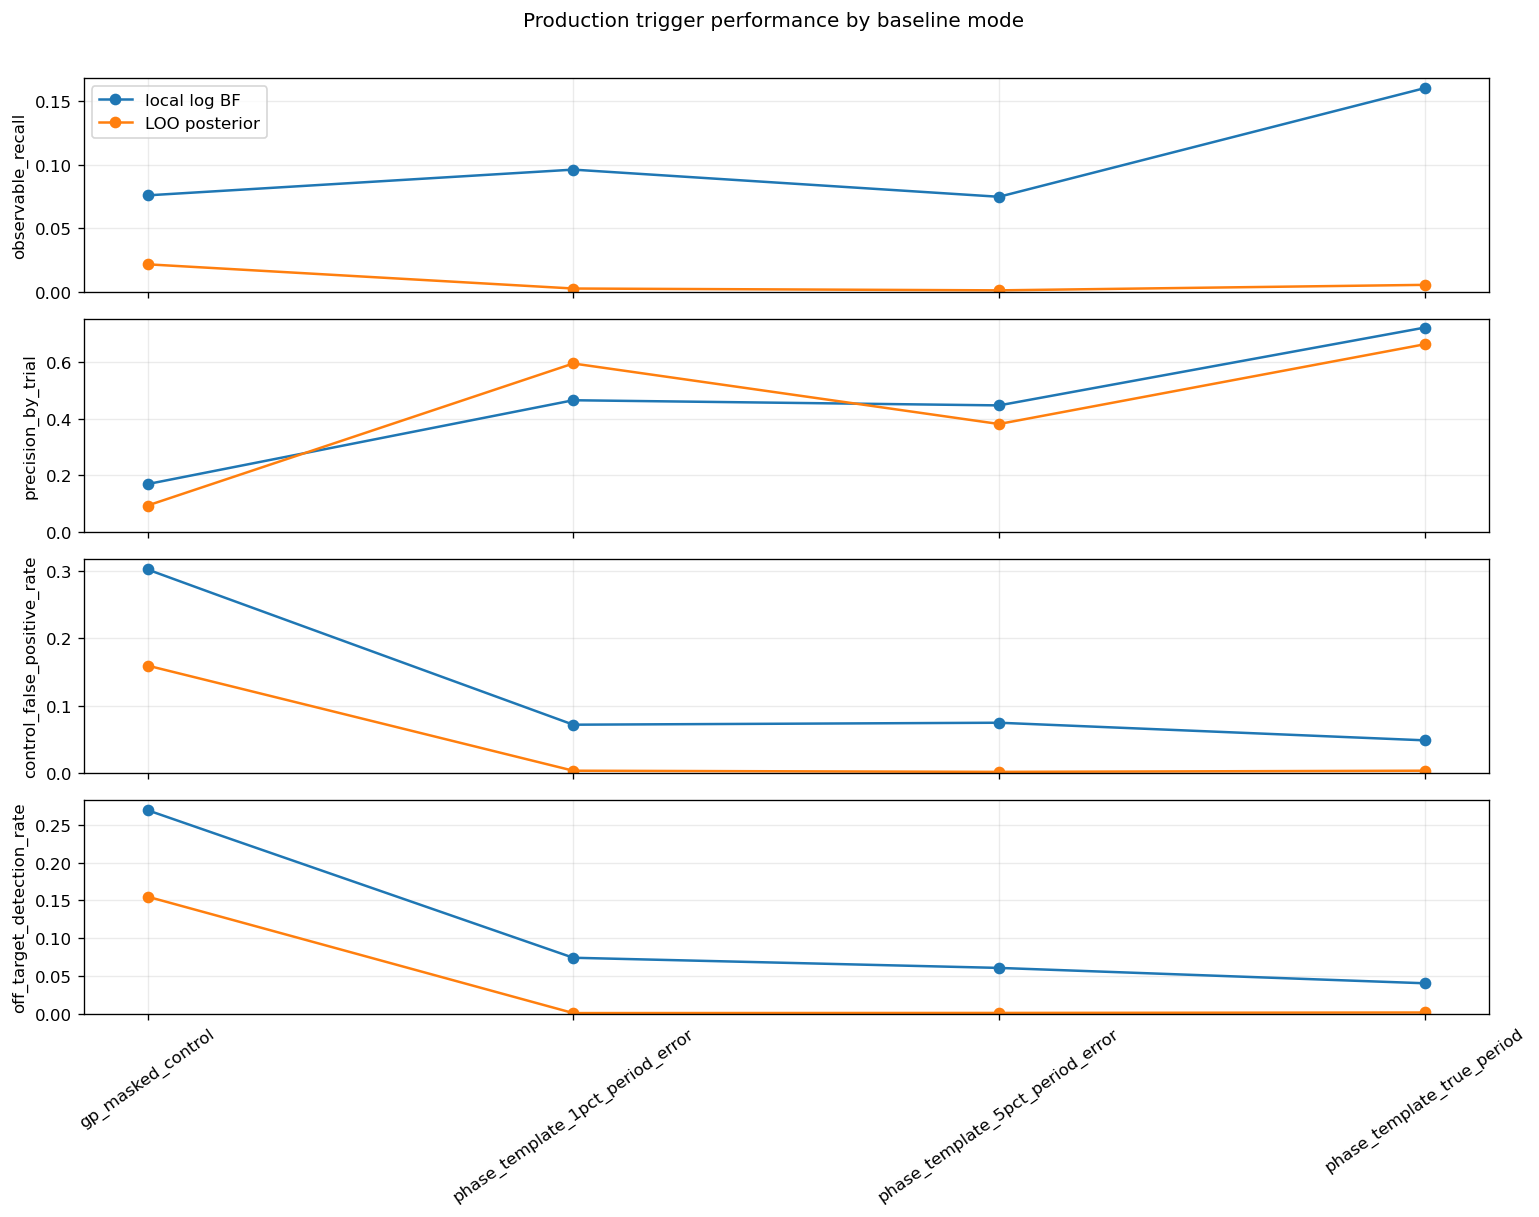

In [6]:
from malca.plotting.lightcurve_publication import finalize_publication_figure
metric_cols = [
    "observable_recall",
    "precision_by_trial",
    "control_false_positive_rate",
    "off_target_detection_rate",
]
plot_df = production_summary.copy()
fig, axes = plt.subplots(len(metric_cols), 1, figsize=(13, 10), sharex=True)
for ax, metric in zip(axes, metric_cols):
    for family, sub in plot_df.groupby("trigger_family"):
        label = "LOO posterior" if family == "loo_posterior_prob" else "local log BF"
        ax.plot(sub["mode"], sub[metric], marker="o", label=label)
    ax.set_ylabel(metric)
    ax.set_ylim(bottom=0)
    ax.grid(alpha=0.25)
axes[0].legend()
axes[-1].tick_params(axis="x", rotation=35)
fig.suptitle("Production trigger performance by baseline mode", y=1.01)
finalize_publication_figure(fig)
fig.savefig(plots_dir / "production_trigger_comparison_by_mode.png")
plt.show()


## Threshold Sweeps

The next plots show how performance changes as the trigger threshold moves. The posterior-probability and log-BF x-axes are not the same physical scale, so compare their rate curves rather than their raw threshold positions.


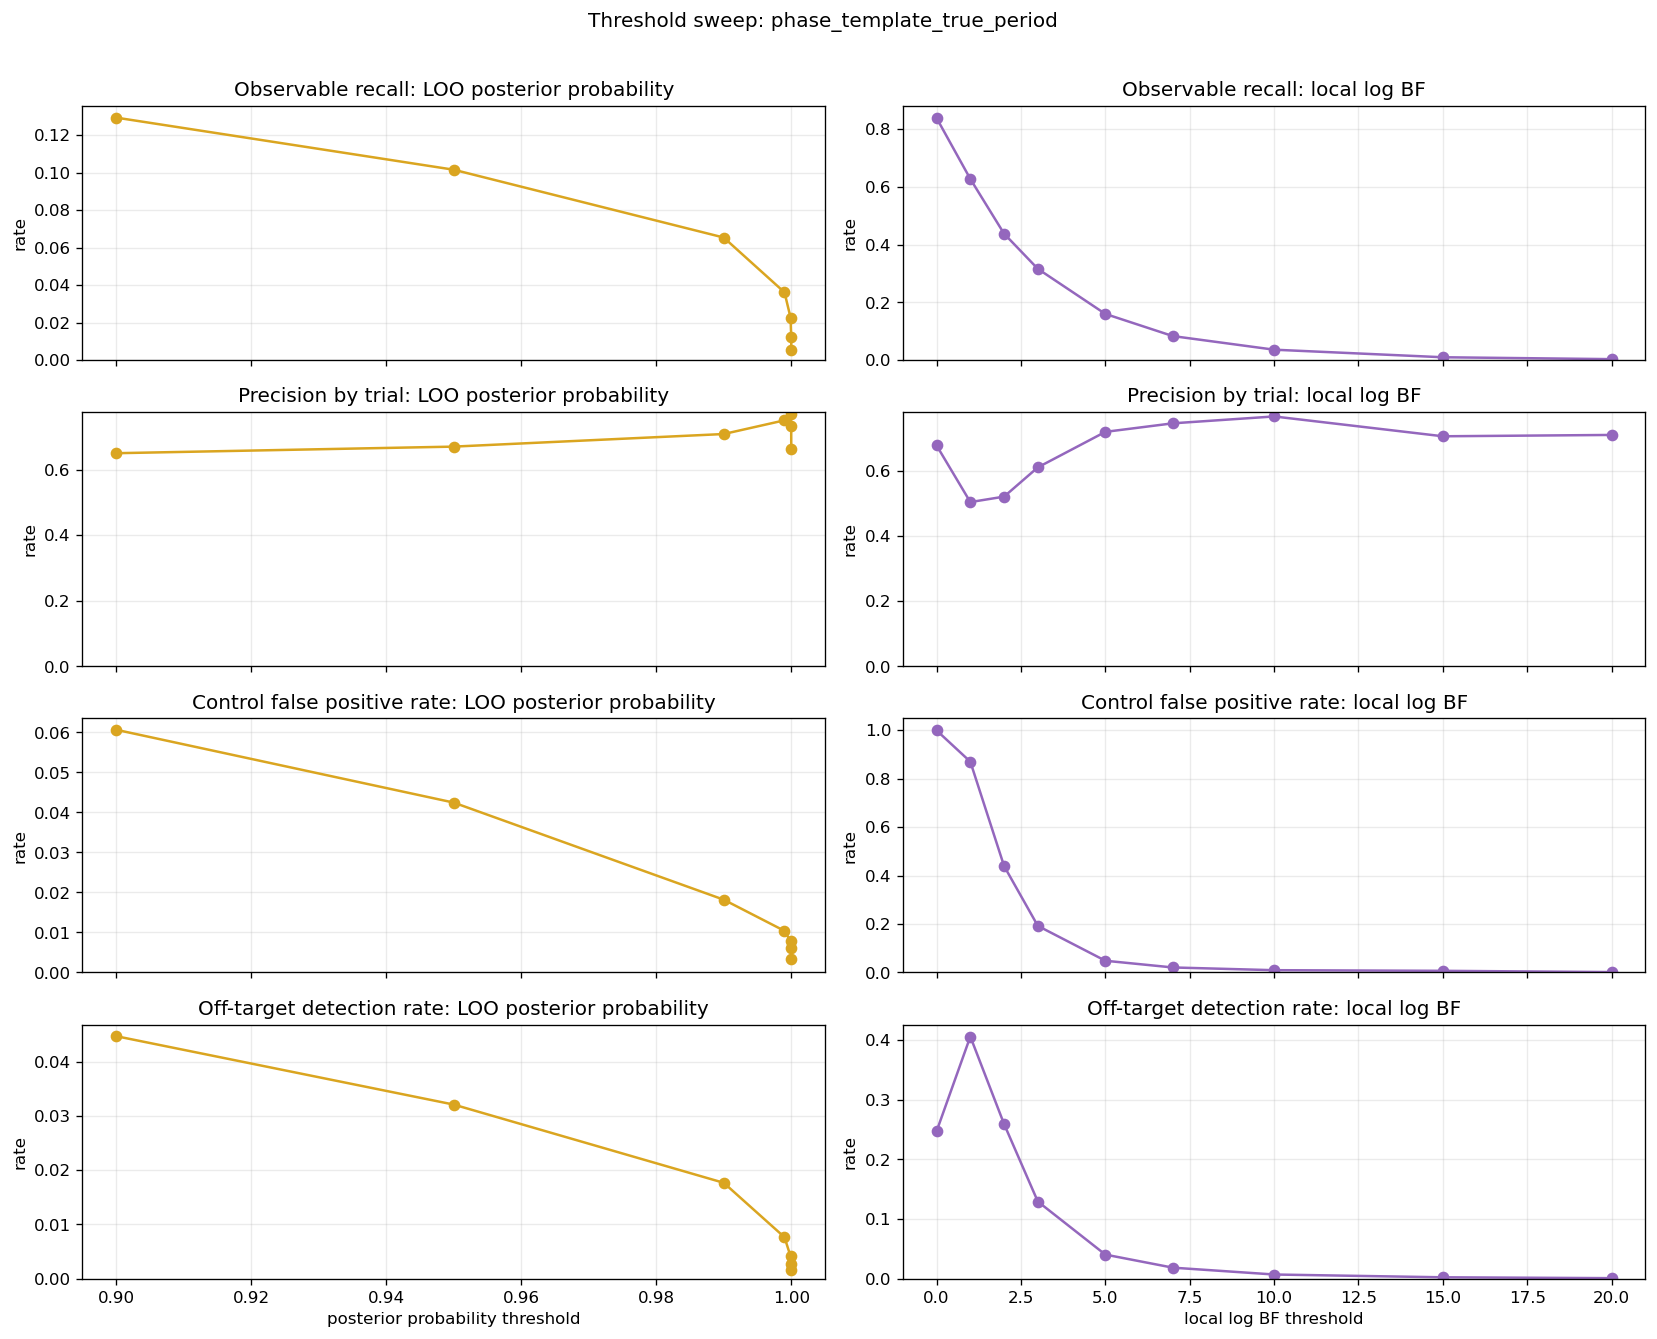

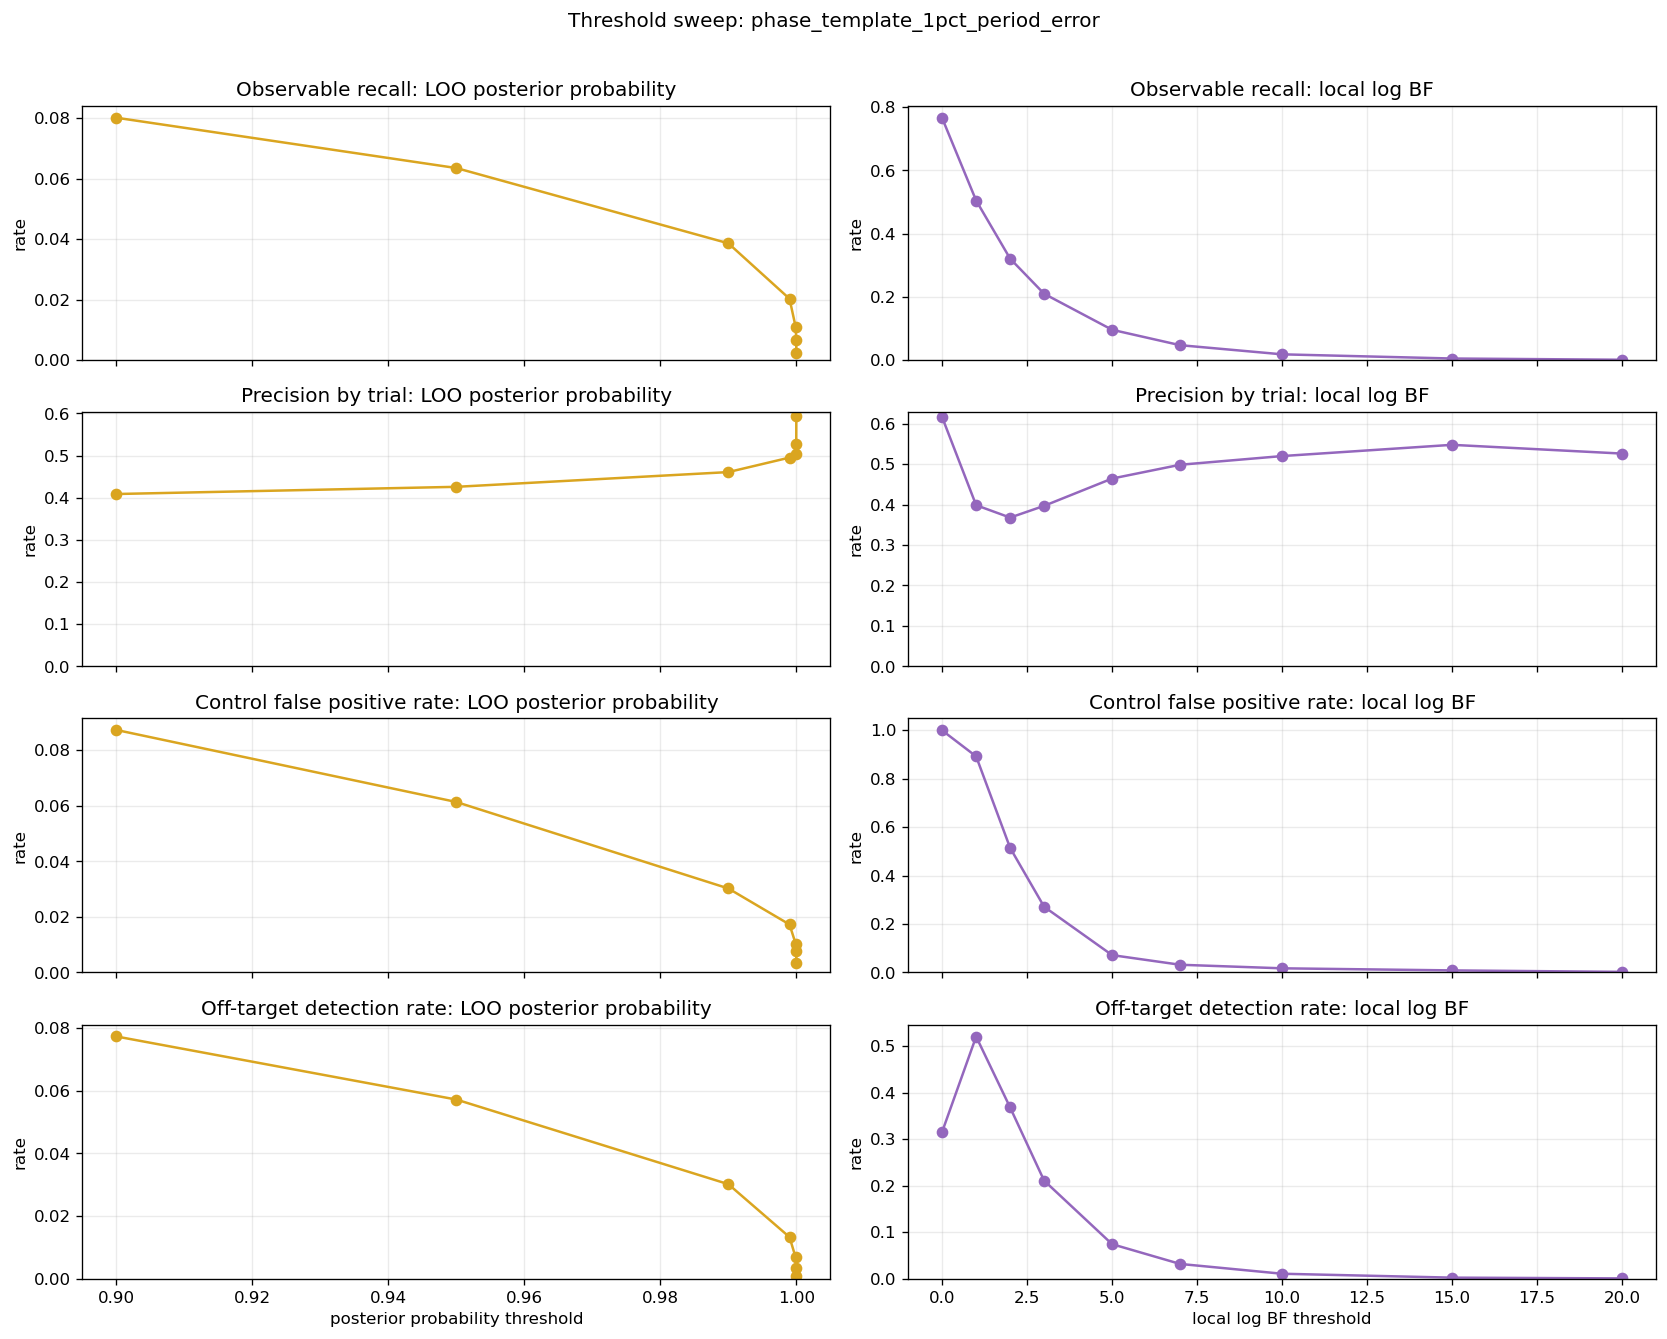

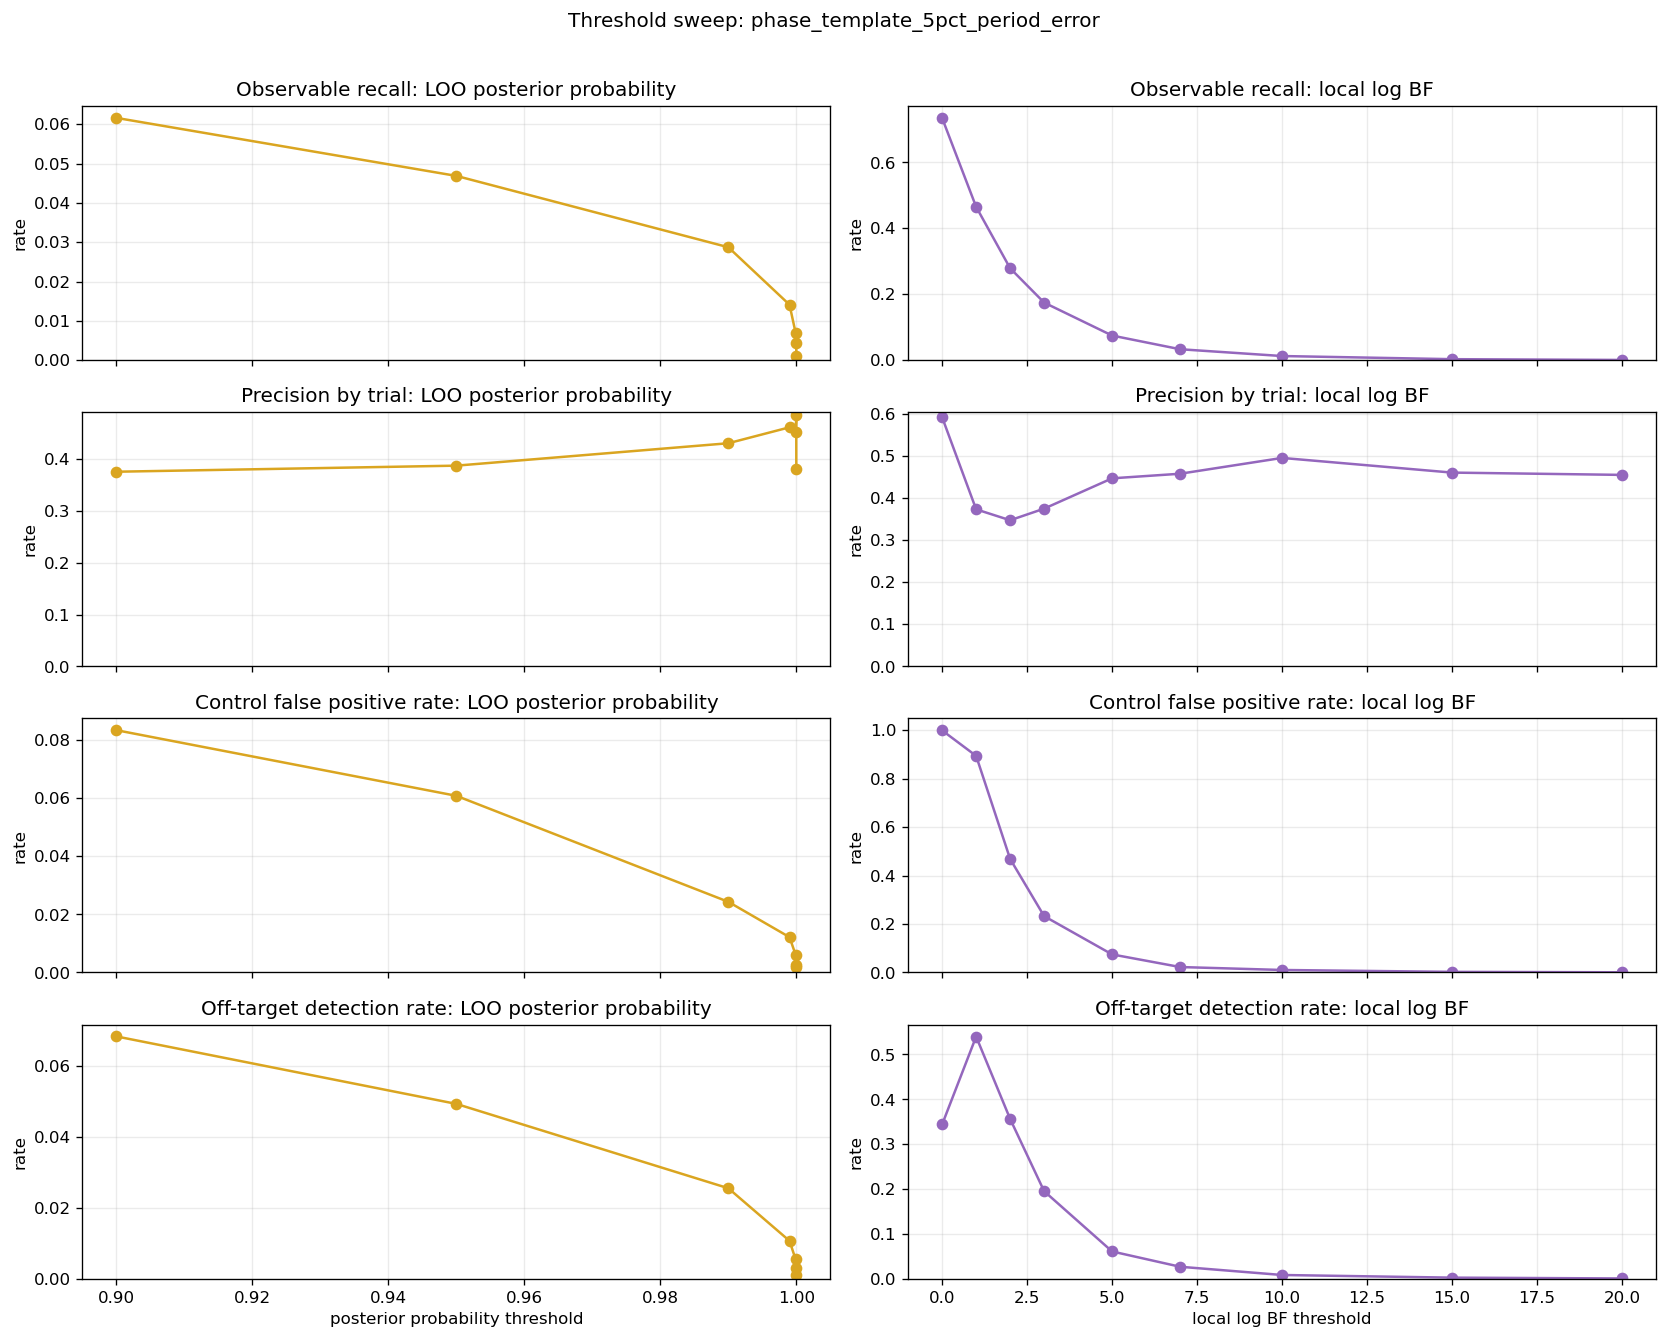

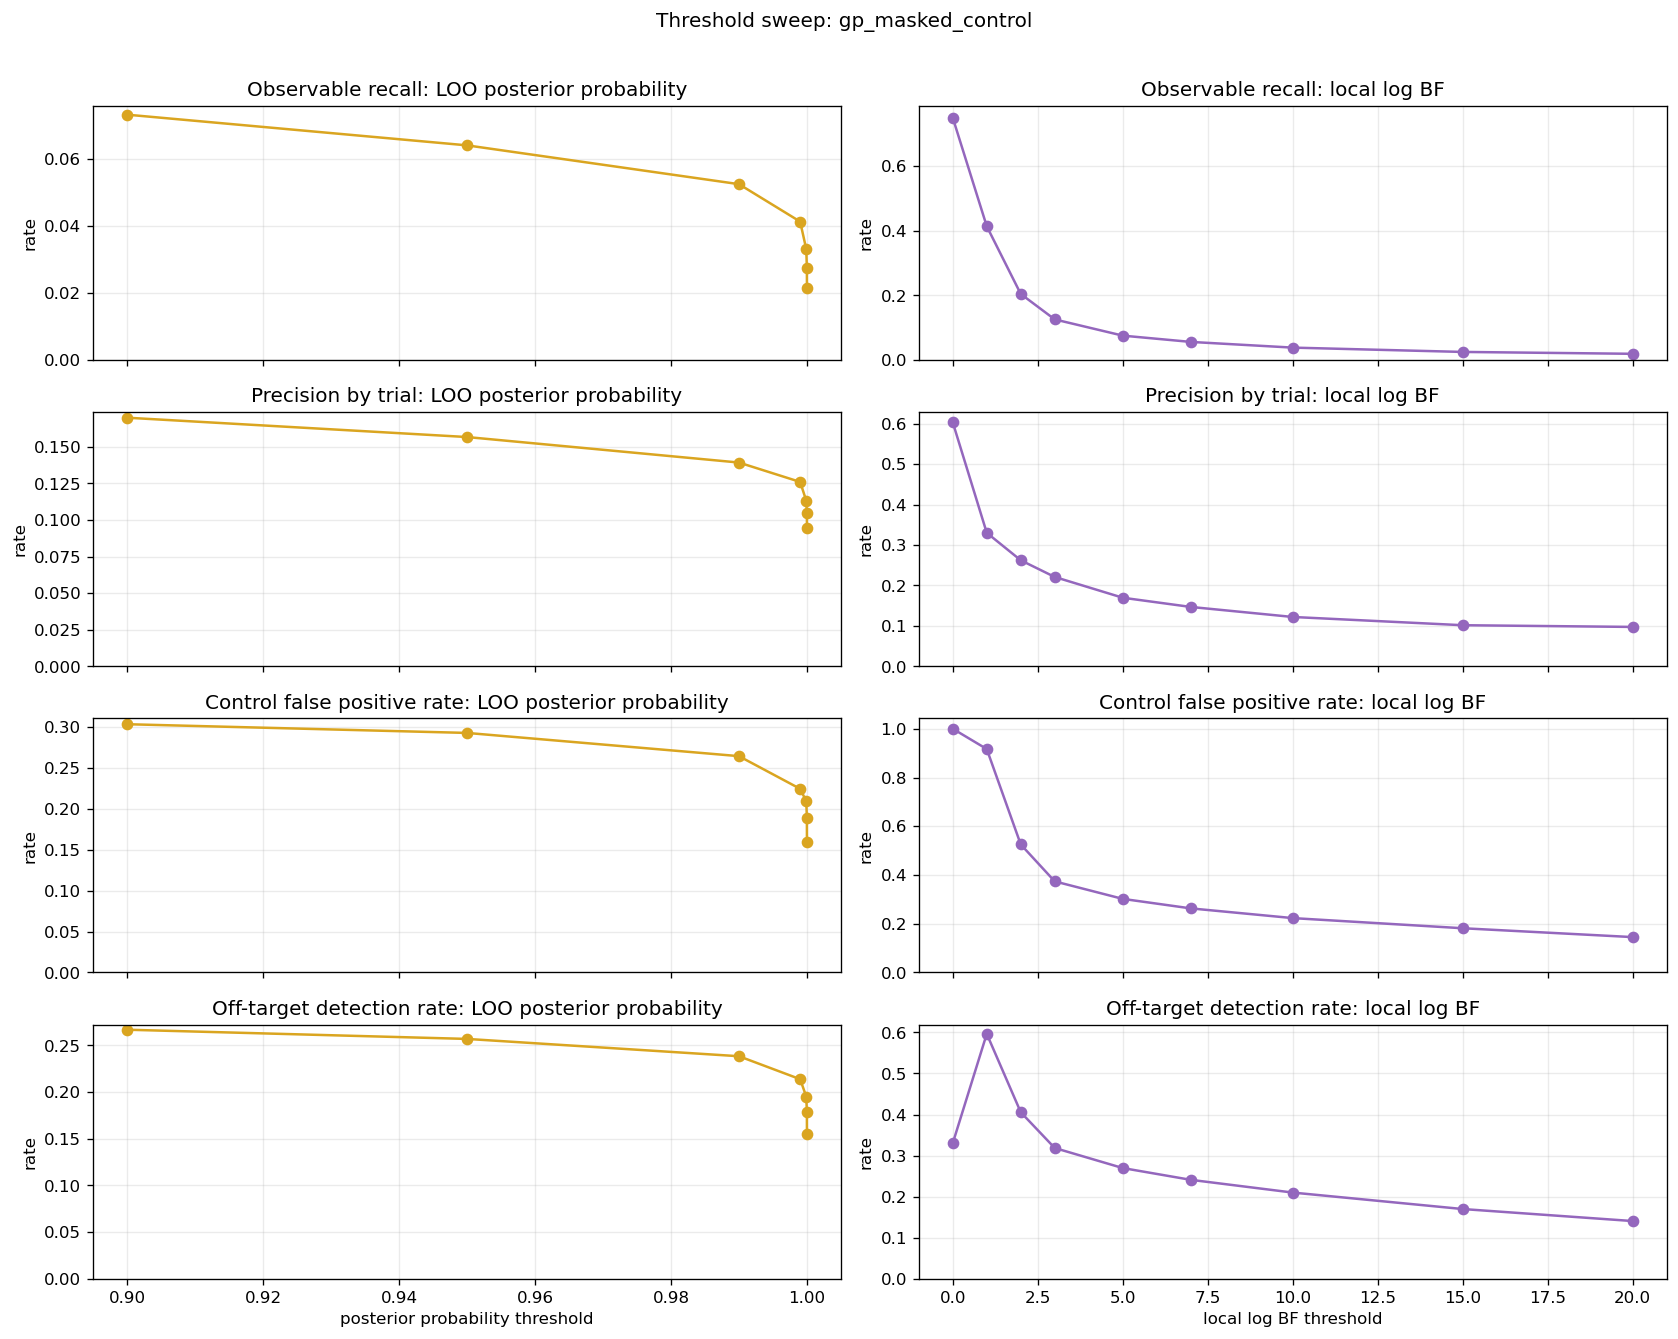

In [7]:
from malca.plotting.lightcurve_publication import finalize_publication_figure
threshold_summary = run.summary_slices["all_thresholds_overall"].copy()
threshold_summary = threshold_summary.sort_values(["mode", "trigger_family", "threshold"])

metrics_to_plot = [
    ("observable_recall", "Observable recall"),
    ("precision_by_trial", "Precision by trial"),
    ("control_false_positive_rate", "Control false positive rate"),
    ("off_target_detection_rate", "Off-target detection rate"),
]
family_labels = {
    "loo_posterior_prob": "LOO posterior probability",
    "local_logbf": "local log BF",
}
family_colors = {
    "loo_posterior_prob": "goldenrod",
    "local_logbf": "tab:purple",
}

for mode in MODE_NAMES:
    sub_mode = threshold_summary[threshold_summary["mode"].eq(mode)].copy()
    if sub_mode.empty:
        continue
    fig, axes = plt.subplots(len(metrics_to_plot), 2, figsize=(14, 11), sharex="col")
    for row_idx, (metric, title) in enumerate(metrics_to_plot):
        for col_idx, family in enumerate(["loo_posterior_prob", "local_logbf"]):
            ax = axes[row_idx, col_idx]
            family_sub = sub_mode[sub_mode["trigger_family"].eq(family)].copy()
            ax.plot(family_sub["threshold"], family_sub[metric], marker="o", color=family_colors[family])
            ax.set_title(f"{title}: {family_labels[family]}")
            ax.set_ylabel("rate")
            ax.set_ylim(bottom=0)
            ax.grid(alpha=0.25)
            if row_idx == len(metrics_to_plot) - 1:
                ax.set_xlabel("posterior probability threshold" if family == "loo_posterior_prob" else "local log BF threshold")
    fig.suptitle(f"Threshold sweep: {mode}", y=1.01)
    finalize_publication_figure(fig)
    fig.savefig(plots_dir / f"threshold_sweep_{mode}.png")
    plt.show()


## Score-Space Relationship

Each row here is one scored light curve under one baseline mode. These plots show whether the strongest local log BF and strongest LOO posterior probability rank the same trials as event-like. Points near high log BF but low LOO probability are candidates where the local evidence spike is not supported by the posterior mixture model; points near high LOO probability but modest log BF are the reverse.


/tmp/ipykernel_2684121/3301564663.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  score_ok["truth_observable_actual"].fillna(False).astype(bool),


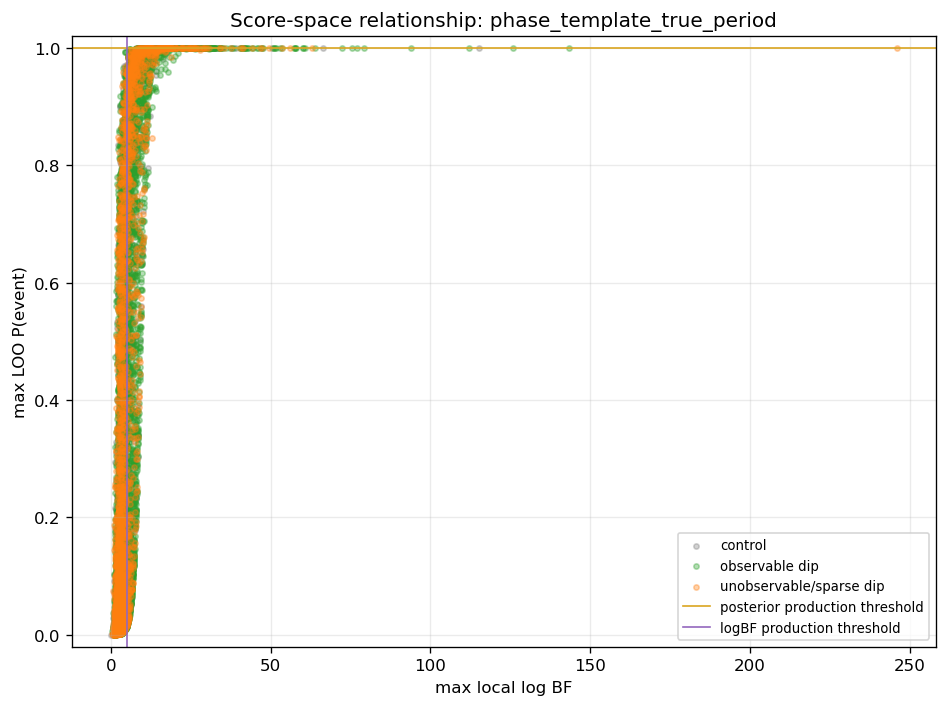

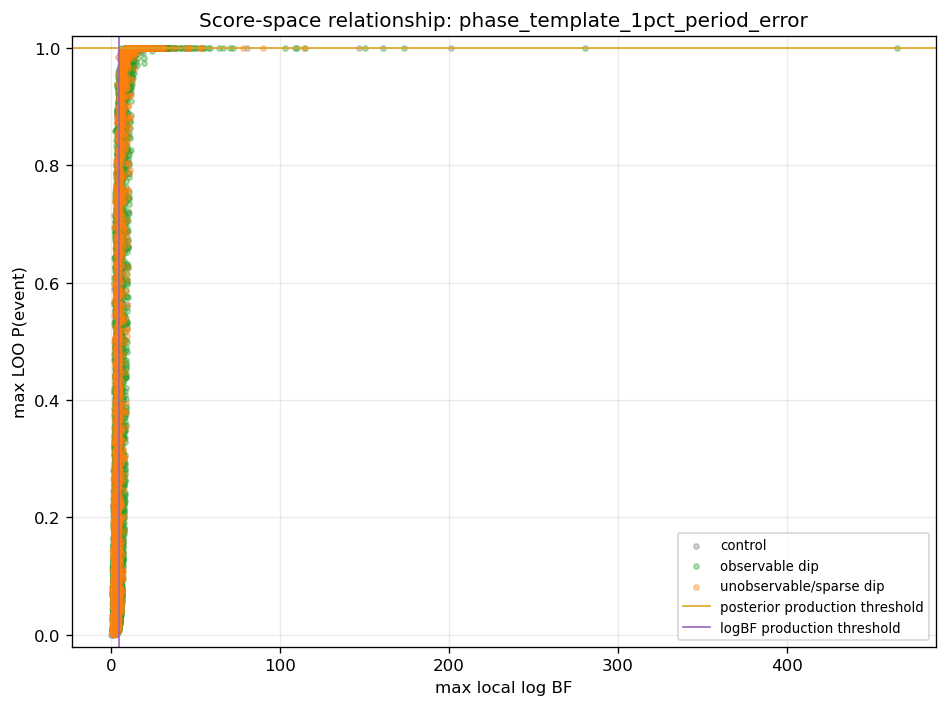

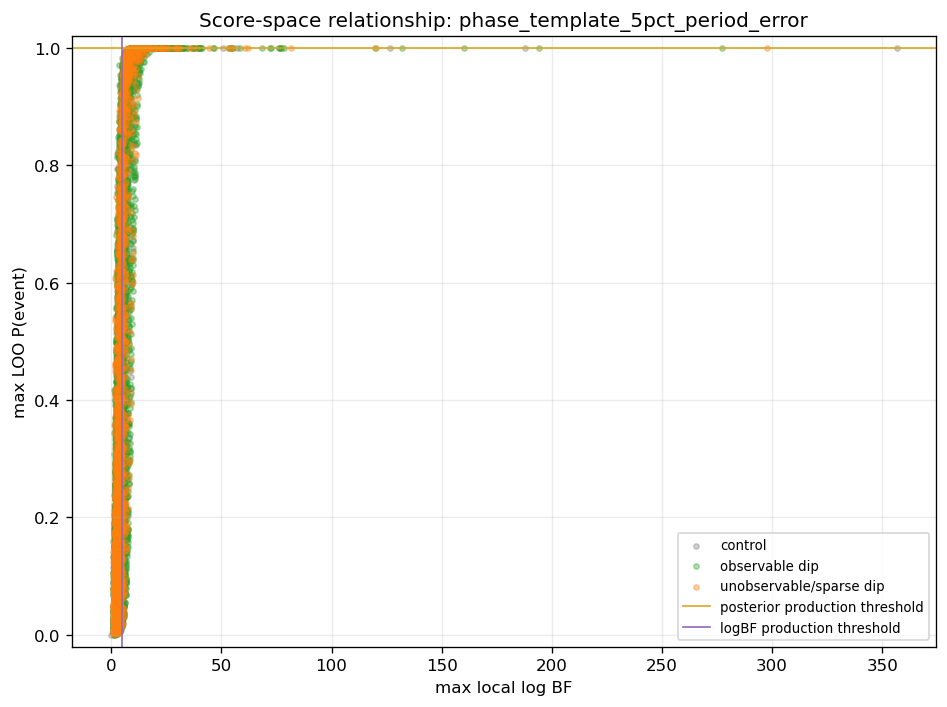

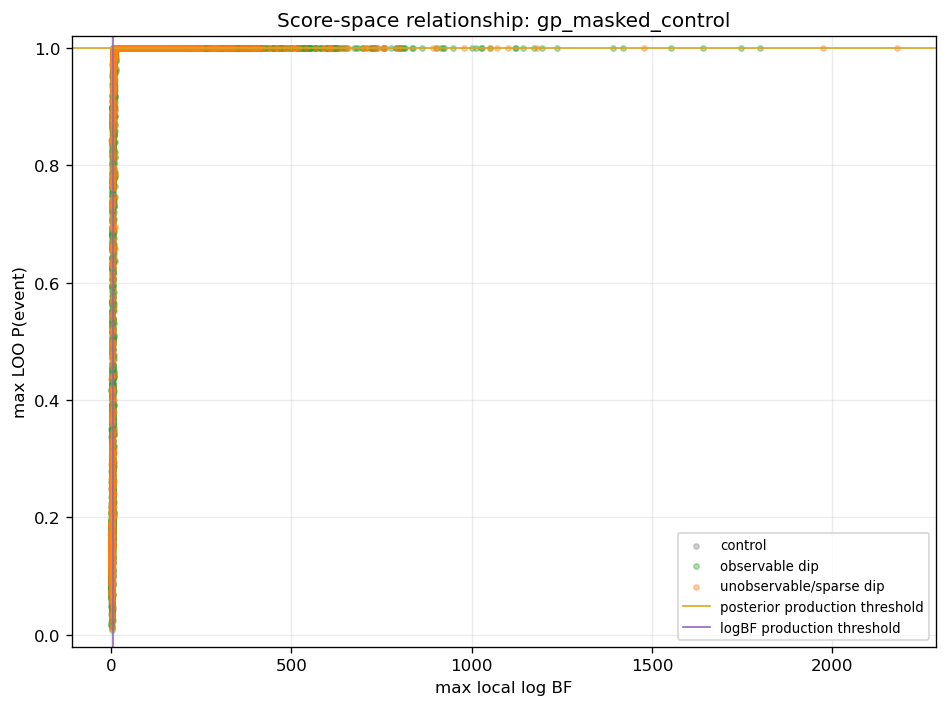

In [8]:
from malca.plotting.lightcurve_publication import (
    FIG_SINGLE_COL_MEDIUM,
    finalize_publication_figure,
)
score_ok = scores[scores["status"].eq("ok")].copy()
score_ok["truth_group"] = np.select(
    [
        ~score_ok["has_dip"].fillna(False).astype(bool),
        score_ok["truth_observable_actual"].fillna(False).astype(bool),
    ],
    ["control", "observable dip"],
    default="unobservable/sparse dip",
)
colors = {"control": "tab:gray", "observable dip": "tab:green", "unobservable/sparse dip": "tab:orange"}

for mode in MODE_NAMES:
    sub = score_ok[score_ok["mode"].eq(mode)].copy()
    if sub.empty:
        continue
    fig, ax = plt.subplots(figsize=FIG_SINGLE_COL_MEDIUM)
    for group, group_sub in sub.groupby("truth_group"):
        ax.scatter(
            group_sub["max_log_bf_local"],
            group_sub["max_event_probability"],
            s=10,
            alpha=0.35,
            label=group,
            color=colors.get(group, None),
        )
    ax.axhline(posterior_probability_threshold(config.significance_threshold), color="goldenrod", lw=1.0, label="posterior production threshold")
    ax.axvline(config.logbf_threshold_dip, color="tab:purple", lw=1.0, label="logBF production threshold")
    ax.set_xlabel("max local log BF")
    ax.set_ylabel("max LOO P(event)")
    ax.set_ylim(-0.02, 1.02)
    ax.set_title(f"Score-space relationship: {mode}")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25)
    finalize_publication_figure(fig)
    fig.savefig(plots_dir / f"score_space_{mode}.png")
    plt.show()


## Production Slices

These tables break production-trigger behavior by injected dip amplitude, period, dip width, sampled point count, and periodic waveform. They are the most useful place to identify where one trigger family wins or fails.


In [9]:
for name in [
    "production_by_amp",
    "production_by_period",
    "production_by_width",
    "production_by_points",
    "production_by_waveform",
]:
    print(f"\n=== {name} ===")
    display(run.summary_slices[name])



=== production_by_amp ===


,mode,trigger_family,dip_amp_bin,n,n_ok,n_dip,n_observable_dip,n_control,status_error_rate,dip_significant_rate,observable_recall,all_dip_recall,control_false_positive_rate,off_target_detection_rate,precision_by_trial,phase_template_fallback_rate,median_raw_trigger_points,median_event_points,median_trigger_max,median_max_event_probability,median_max_log_bf_local,median_bayes_factor,median_baseline_mae_outside_dip,median_resid_rms_outside_dip,median_amp_recovery_ratio
0,gp_masked_control,local_logbf,0.06-0.10,3039,2879,2879,1405,0,0.052649,0.311567,0.022776,0.023619,NaN,0.287947,0.075808,0.000000,0.0,0.0,4.678128,0.635430,4.678128,-0.235172,0.143410,0.184405,2.332019
1,gp_masked_control,local_logbf,0.10-0.18,4112,3896,3896,3000,0,0.052529,0.325205,0.051667,0.044918,NaN,0.280287,0.138122,0.000000,1.0,0.0,5.120238,0.736417,5.120238,0.389607,0.142881,0.183540,1.956741
2,gp_masked_control,local_logbf,0.18-0.26,2011,1917,1917,1693,0,0.046743,0.336985,0.101595,0.092853,NaN,0.244131,0.275542,0.000000,1.0,0.0,5.521625,0.762407,5.521625,0.550354,0.145543,0.186202,1.679344
3,gp_masked_control,local_logbf,0.26+,1646,1550,1550,1331,0,0.058323,0.377419,0.153268,0.137419,NaN,0.240000,0.364103,0.000000,1.0,0.0,6.311838,0.882037,6.311838,1.681141,0.146790,0.187728,1.419365
4,gp_masked_control,local_logbf,control,1192,1129,0,0,1129,0.052852,0.302037,NaN,NaN,0.302037,NaN,0.000000,0.000000,0.0,0.0,4.567606,0.502040,4.567606,-0.641381,0.142449,0.183644,NaN
5,gp_masked_control,loo_posterior_prob,0.06-0.10,3039,2879,2879,1405,0,0.052649,0.162556,0.011388,0.011115,NaN,0.151441,0.068376,0.000000,0.0,0.0,0.635430,0.635430,4.678128,-0.235172,0.143410,0.184405,2.332019
6,gp_masked_control,loo_posterior_prob,0.10-0.18,4112,3896,3896,3000,0,0.052529,0.176591,0.015000,0.012834,NaN,0.163758,0.072674,0.000000,0.0,0.0,0.736417,0.736417,5.120238,0.389607,0.142881,0.183540,1.956741
7,gp_masked_control,loo_posterior_prob,0.18-0.26,2011,1917,1917,1693,0,0.046743,0.172144,0.032487,0.029212,NaN,0.142932,0.169697,0.000000,0.0,0.0,0.762407,0.762407,5.521625,0.550354,0.145543,0.186202,1.679344
8,gp_masked_control,loo_posterior_prob,0.26+,1646,1550,1550,1331,0,0.058323,0.184516,0.033058,0.029677,NaN,0.154839,0.160839,0.000000,0.0,0.0,0.882037,0.882037,6.311838,1.681141,0.146790,0.187728,1.419365
9,gp_masked_control,loo_posterior_prob,control,1192,1129,0,0,1129,0.052852,0.159433,NaN,NaN,0.159433,NaN,0.000000,0.000000,0.0,0.0,0.502040,0.502040,4.567606,-0.641381,0.142449,0.183644,NaN



=== production_by_period ===


,mode,trigger_family,period_bin,n,n_ok,n_dip,n_observable_dip,n_control,status_error_rate,dip_significant_rate,observable_recall,all_dip_recall,control_false_positive_rate,off_target_detection_rate,precision_by_trial,phase_template_fallback_rate,median_raw_trigger_points,median_event_points,median_trigger_max,median_max_event_probability,median_max_log_bf_local,median_bayes_factor,median_baseline_mae_outside_dip,median_resid_rms_outside_dip,median_amp_recovery_ratio
0,gp_masked_control,local_logbf,10-25d,2433,2314,2110,1558,204,0.048911,0.324546,0.066752,0.056398,0.264706,0.273934,0.158455,0.000000,1.0,0.0,5.515099,0.778869,5.515099,0.949109,0.144794,0.185644,1.768332
1,gp_masked_control,local_logbf,2-5d,2340,2209,1969,1377,240,0.055983,0.326845,0.072622,0.056374,0.295833,0.274251,0.153740,0.000000,1.0,0.0,5.473999,0.788168,5.473999,0.634860,0.141668,0.182065,1.849934
2,gp_masked_control,local_logbf,25-50d,1824,1728,1539,1144,189,0.052632,0.326968,0.085664,0.072125,0.264550,0.262508,0.196460,0.000000,0.0,0.0,4.775726,0.562064,4.775726,-0.408247,0.142841,0.184290,1.718426
3,gp_masked_control,local_logbf,5-10d,1804,1719,1570,1123,149,0.047118,0.336242,0.077471,0.062420,0.355705,0.271975,0.169550,0.000000,1.0,0.0,5.066416,0.656187,5.066416,-0.135732,0.144853,0.185114,1.799291
4,gp_masked_control,local_logbf,50d+,1191,1127,1006,732,121,0.053736,0.342502,0.073770,0.058648,0.355372,0.282306,0.152850,0.000000,1.0,0.0,5.412714,0.777626,5.412714,0.790736,0.142722,0.183141,1.646498
5,gp_masked_control,local_logbf,<2d,2408,2274,2048,1495,226,0.055648,0.322779,0.080268,0.066406,0.309735,0.257812,0.185286,0.000000,1.0,0.0,5.031485,0.710478,5.031485,0.294070,0.146328,0.188290,1.803277
6,gp_masked_control,loo_posterior_prob,10-25d,2433,2314,2110,1558,204,0.048911,0.168107,0.020539,0.018483,0.127451,0.153555,0.100257,0.000000,0.0,0.0,0.778869,0.778869,5.515099,0.949109,0.144794,0.185644,1.768332
7,gp_masked_control,loo_posterior_prob,2-5d,2340,2209,1969,1377,240,0.055983,0.175645,0.018882,0.014220,0.166667,0.162519,0.072165,0.000000,0.0,0.0,0.788168,0.788168,5.473999,0.634860,0.141668,0.182065,1.849934
8,gp_masked_control,loo_posterior_prob,25-50d,1824,1728,1539,1144,189,0.052632,0.171296,0.020105,0.019493,0.142857,0.155296,0.101351,0.000000,0.0,0.0,0.562064,0.562064,4.775726,-0.408247,0.142841,0.184290,1.718426
9,gp_masked_control,loo_posterior_prob,5-10d,1804,1719,1570,1123,149,0.047118,0.178010,0.024933,0.018471,0.174497,0.159873,0.094771,0.000000,0.0,0.0,0.656187,0.656187,5.066416,-0.135732,0.144853,0.185114,1.799291



=== production_by_width ===


,mode,trigger_family,width_bin,n,n_ok,n_dip,n_observable_dip,n_control,status_error_rate,dip_significant_rate,observable_recall,all_dip_recall,control_false_positive_rate,off_target_detection_rate,precision_by_trial,phase_template_fallback_rate,median_raw_trigger_points,median_event_points,median_trigger_max,median_max_event_probability,median_max_log_bf_local,median_bayes_factor,median_baseline_mae_outside_dip,median_resid_rms_outside_dip,median_amp_recovery_ratio
0,gp_masked_control,local_logbf,0.5-1.5d,4141,3932,3932,2672,0,0.050471,0.325788,0.061377,0.048830,NaN,0.276958,0.149883,0.000000,1.0,0.0,5.092792,0.668867,5.092792,-0.065441,0.144563,0.184867,1.682807
1,gp_masked_control,local_logbf,1.5-4d,3066,2894,2894,2331,0,0.056099,0.346579,0.078936,0.070145,NaN,0.276434,0.202393,0.000000,1.0,0.0,5.515153,0.779158,5.515153,1.003962,0.143183,0.185234,1.914711
2,gp_masked_control,local_logbf,10d+,340,323,323,317,0,0.050000,0.343653,0.154574,0.151703,NaN,0.191950,0.441441,0.000000,1.0,0.0,5.957712,0.825661,5.957712,0.404483,0.144026,0.186256,2.312763
3,gp_masked_control,local_logbf,4-10d,1083,1028,1028,991,0,0.050785,0.333658,0.121090,0.118677,NaN,0.214981,0.355685,0.000000,1.0,0.0,5.319518,0.751017,5.319518,0.356980,0.144758,0.184808,1.924980
4,gp_masked_control,local_logbf,<0.5d,2178,2065,2065,1118,0,0.051882,0.318160,0.041145,0.032930,NaN,0.285230,0.103501,0.000000,1.0,0.0,5.080403,0.764489,5.080403,0.620992,0.144163,0.185104,1.509084
5,gp_masked_control,local_logbf,nan,1192,1129,0,0,1129,0.052852,0.302037,NaN,NaN,0.302037,NaN,0.000000,0.000000,0.0,0.0,4.567606,0.502040,4.567606,-0.641381,0.142449,0.183644,NaN
6,gp_masked_control,loo_posterior_prob,0.5-1.5d,4141,3932,3932,2672,0,0.050471,0.169125,0.017590,0.015005,NaN,0.154120,0.088722,0.000000,0.0,0.0,0.668867,0.668867,5.092792,-0.065441,0.144563,0.184867,1.682807
7,gp_masked_control,loo_posterior_prob,1.5-4d,3066,2894,2894,2331,0,0.056099,0.177954,0.016731,0.014858,NaN,0.163096,0.083495,0.000000,0.0,0.0,0.779158,0.779158,5.515153,1.003962,0.143183,0.185234,1.914711
8,gp_masked_control,loo_posterior_prob,10d+,340,323,323,317,0,0.050000,0.185759,0.066246,0.065015,NaN,0.120743,0.350000,0.000000,0.0,0.0,0.825661,0.825661,5.957712,0.404483,0.144026,0.186256,2.312763
9,gp_masked_control,loo_posterior_prob,4-10d,1083,1028,1028,991,0,0.050785,0.169261,0.039354,0.038911,NaN,0.130350,0.229885,0.000000,0.0,0.0,0.751017,0.751017,5.319518,0.356980,0.144758,0.184808,1.924980



=== production_by_points ===


,mode,trigger_family,points_bin_actual,n,n_ok,n_dip,n_observable_dip,n_control,status_error_rate,dip_significant_rate,observable_recall,all_dip_recall,control_false_positive_rate,off_target_detection_rate,precision_by_trial,phase_template_fallback_rate,median_raw_trigger_points,median_event_points,median_trigger_max,median_max_event_probability,median_max_log_bf_local,median_bayes_factor,median_baseline_mae_outside_dip,median_resid_rms_outside_dip,median_amp_recovery_ratio
0,gp_masked_control,local_logbf,120-220,2001,2001,1794,1178,207,0.0,0.520740,0.118846,0.093645,0.487923,0.430881,0.161228,0.000000,3.0,2.0,23.150001,1.000000,23.150001,45.688670,0.140988,0.182283,1.577063
1,gp_masked_control,local_logbf,220-360,3106,3106,2793,1997,313,0.0,0.349646,0.077616,0.058360,0.303514,0.296455,0.150092,0.000000,1.0,0.0,6.626562,0.954587,6.626562,3.852502,0.143493,0.184926,1.747232
2,gp_masked_control,local_logbf,360-520,3529,3529,3181,2425,348,0.0,0.238595,0.060619,0.047784,0.215517,0.193335,0.180523,0.000000,0.0,0.0,3.730792,0.216344,3.730792,-1.552860,0.145412,0.186182,1.876191
3,gp_masked_control,local_logbf,520+,2148,2148,1943,1527,205,0.0,0.186220,0.049116,0.039629,0.170732,0.148224,0.192500,0.000000,0.0,0.0,3.061140,0.150823,3.061140,-1.746312,0.147607,0.185808,1.904090
4,gp_masked_control,local_logbf,<120,587,587,531,302,56,0.0,0.623509,0.152318,0.139360,0.625000,0.483992,0.202186,0.000000,5.0,3.0,37.700206,1.000000,37.700206,94.963434,0.135032,0.181088,1.509696
5,gp_masked_control,local_logbf,nan,629,0,0,0,0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,gp_masked_control,loo_posterior_prob,120-220,2001,2001,1794,1178,207,0.0,0.304848,0.047538,0.038462,0.285024,0.268673,0.113115,0.000000,1.0,0.0,1.000000,1.000000,23.150001,45.688670,0.140988,0.182283,1.577063
7,gp_masked_control,loo_posterior_prob,220-360,3106,3106,2793,1997,313,0.0,0.187057,0.025038,0.018618,0.166134,0.170784,0.089501,0.000000,0.0,0.0,0.954587,0.954587,6.626562,3.852502,0.143493,0.184926,1.747232
8,gp_masked_control,loo_posterior_prob,360-520,3529,3529,3181,2425,348,0.0,0.103145,0.010309,0.007859,0.097701,0.095882,0.068681,0.000000,0.0,0.0,0.216344,0.216344,3.730792,-1.552860,0.145412,0.186182,1.876191
9,gp_masked_control,loo_posterior_prob,520+,2148,2148,1943,1527,205,0.0,0.080540,0.008513,0.007205,0.073171,0.074112,0.080925,0.000000,0.0,0.0,0.150823,0.150823,3.061140,-1.746312,0.147607,0.185808,1.904090



=== production_by_waveform ===


,mode,trigger_family,waveform_kind,n,n_ok,n_dip,n_observable_dip,n_control,status_error_rate,dip_significant_rate,observable_recall,all_dip_recall,control_false_positive_rate,off_target_detection_rate,precision_by_trial,phase_template_fallback_rate,median_raw_trigger_points,median_event_points,median_trigger_max,median_max_event_probability,median_max_log_bf_local,median_bayes_factor,median_baseline_mae_outside_dip,median_resid_rms_outside_dip,median_amp_recovery_ratio
0,gp_masked_control,local_logbf,broad_eclipse,2390,2232,2010,1454,222,0.066109,0.397849,0.116919,0.091045,0.387387,0.307960,0.206081,0.000000,2.0,0.0,8.058042,0.990200,8.058042,11.122136,0.135714,0.169903,1.734782
1,gp_masked_control,local_logbf,double_wave,2332,2227,1982,1428,245,0.045026,0.315222,0.077031,0.061049,0.265306,0.260343,0.172365,0.000000,0.0,0.0,4.640775,0.518979,4.640775,-0.578907,0.142397,0.186197,1.740130
2,gp_masked_control,local_logbf,mixed,2476,2330,2112,1528,218,0.058966,0.308155,0.066099,0.055398,0.284404,0.255208,0.162953,0.000000,0.0,0.0,4.561037,0.447215,4.561037,-0.827581,0.142810,0.185867,1.808161
3,gp_masked_control,local_logbf,sinusoid,2393,2284,2064,1523,220,0.045550,0.306042,0.059094,0.047965,0.286364,0.260174,0.141631,0.000000,0.0,0.0,4.476723,0.329083,4.476723,-1.252466,0.150936,0.194003,1.828839
4,gp_masked_control,local_logbf,spot_like,2409,2298,2074,1496,224,0.046077,0.317232,0.061497,0.054966,0.290179,0.265188,0.156379,0.000000,0.0,0.0,4.580812,0.500866,4.580812,-0.754332,0.145860,0.186935,1.776933
5,gp_masked_control,loo_posterior_prob,broad_eclipse,2390,2232,2010,1454,222,0.066109,0.171595,0.027510,0.022388,0.157658,0.150746,0.117493,0.000000,0.0,0.0,0.990200,0.990200,8.058042,11.122136,0.135714,0.169903,1.734782
6,gp_masked_control,loo_posterior_prob,double_wave,2332,2227,1982,1428,245,0.045026,0.175573,0.021008,0.017154,0.171429,0.158930,0.086957,0.000000,0.0,0.0,0.518979,0.518979,4.640775,-0.578907,0.142397,0.186197,1.740130
7,gp_masked_control,loo_posterior_prob,mixed,2476,2330,2112,1528,218,0.058966,0.165236,0.017670,0.014678,0.137615,0.153409,0.080519,0.000000,0.0,0.0,0.447215,0.447215,4.561037,-0.827581,0.142810,0.185867,1.808161
8,gp_masked_control,loo_posterior_prob,sinusoid,2393,2284,2064,1523,220,0.045550,0.169440,0.024294,0.018895,0.168182,0.150678,0.100775,0.000000,0.0,0.0,0.329083,0.329083,4.476723,-1.252466,0.150936,0.194003,1.828839
9,gp_masked_control,loo_posterior_prob,spot_like,2409,2298,2074,1496,224,0.046077,0.176675,0.017380,0.016876,0.160714,0.161524,0.086207,0.000000,0.0,0.0,0.500866,0.500866,4.580812,-0.754332,0.145860,0.186935,1.776933


## Recovery Heatmaps

Heatmaps are shown separately for each production trigger family and baseline mode. Brighter cells mean higher target recovery among trials in that slice. The denominator is all trials in the slice, with `observable_recall` focused only on dips that had enough sampled truth support to be plausible detections.


/tmp/ipykernel_2684121/2702391353.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  & df["truth_observable_actual"].fillna(False).astype(bool)
/tmp/ipykernel_2684121/2702391353.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  table = sub.pivot_table(index=row, columns=col, values=metric, aggfunc=lambda x: np.mean(pd.Series(x).fillna(False).astype(bool)))
/tmp/ipykernel_2684121/2702391353.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=

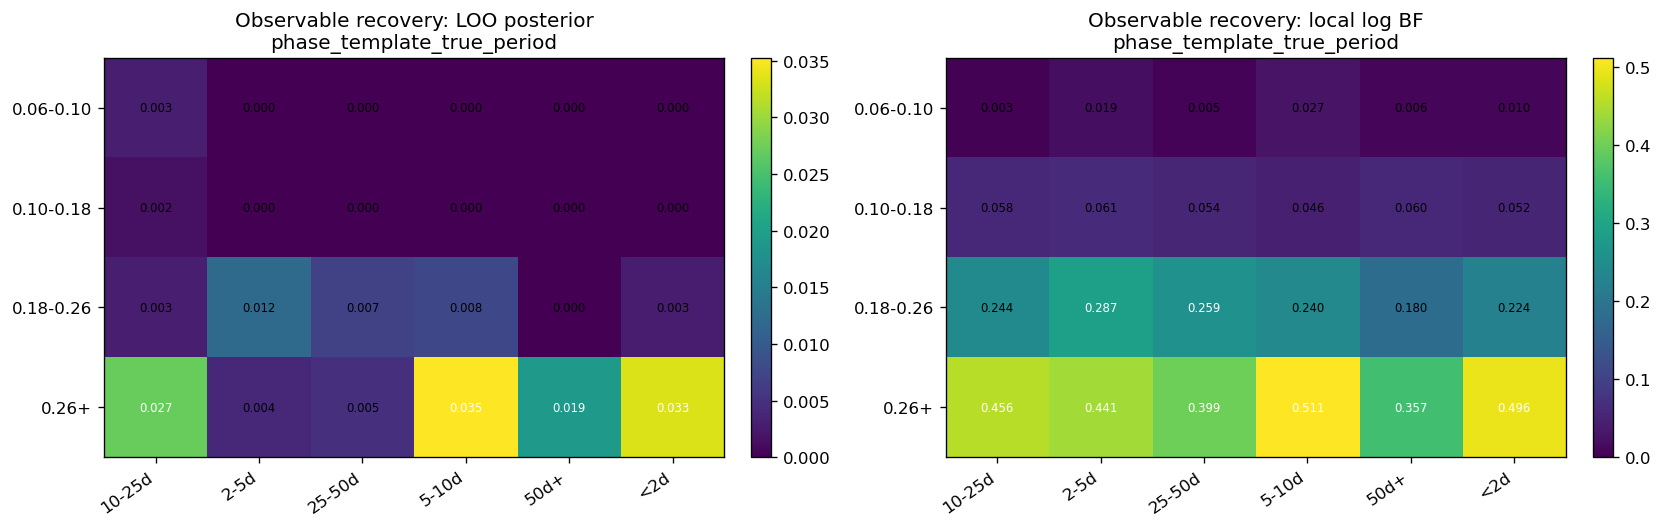

/tmp/ipykernel_2684121/2702391353.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  & df["truth_observable_actual"].fillna(False).astype(bool)
/tmp/ipykernel_2684121/2702391353.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  table = sub.pivot_table(index=row, columns=col, values=metric, aggfunc=lambda x: np.mean(pd.Series(x).fillna(False).astype(bool)))
/tmp/ipykernel_2684121/2702391353.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=

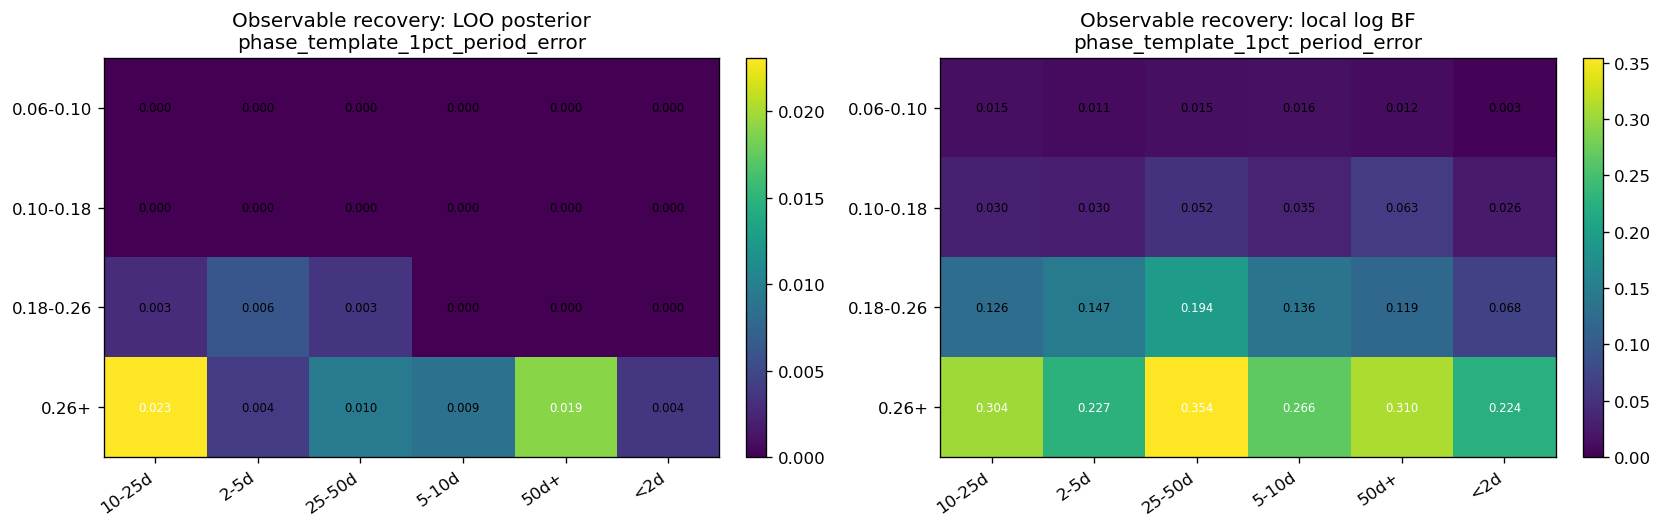

/tmp/ipykernel_2684121/2702391353.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  & df["truth_observable_actual"].fillna(False).astype(bool)
/tmp/ipykernel_2684121/2702391353.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  table = sub.pivot_table(index=row, columns=col, values=metric, aggfunc=lambda x: np.mean(pd.Series(x).fillna(False).astype(bool)))
/tmp/ipykernel_2684121/2702391353.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=

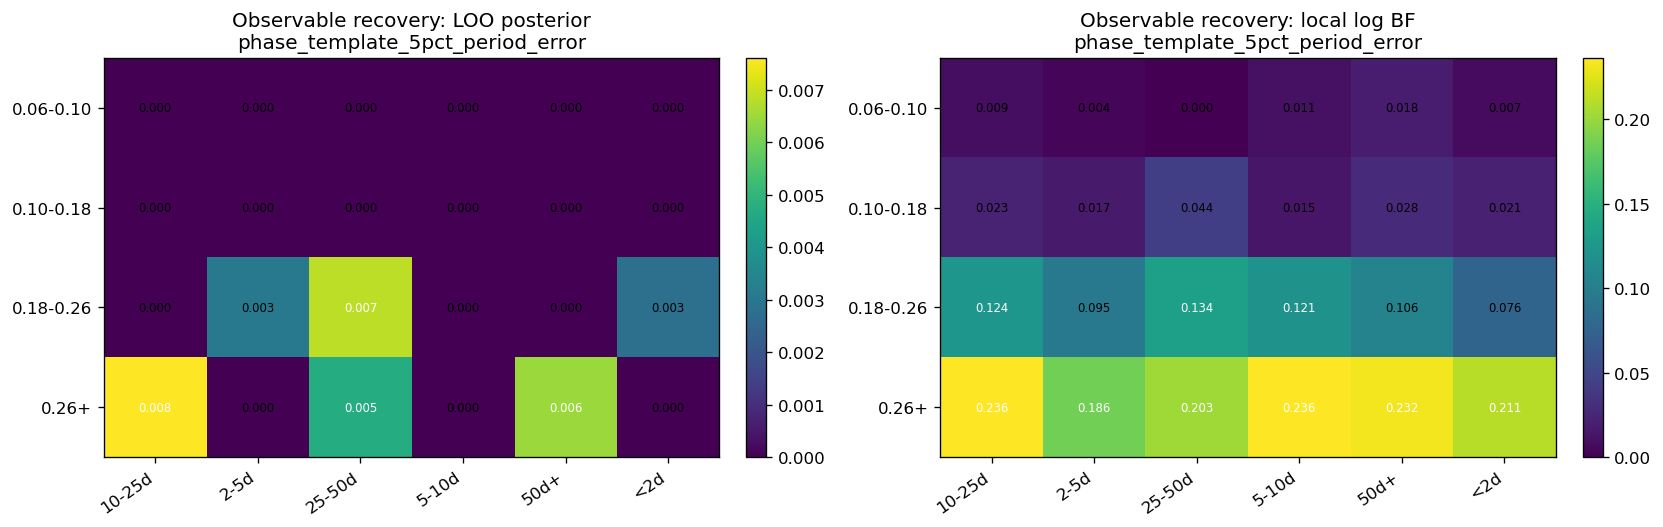

/tmp/ipykernel_2684121/2702391353.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  & df["truth_observable_actual"].fillna(False).astype(bool)
/tmp/ipykernel_2684121/2702391353.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  table = sub.pivot_table(index=row, columns=col, values=metric, aggfunc=lambda x: np.mean(pd.Series(x).fillna(False).astype(bool)))
/tmp/ipykernel_2684121/2702391353.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=

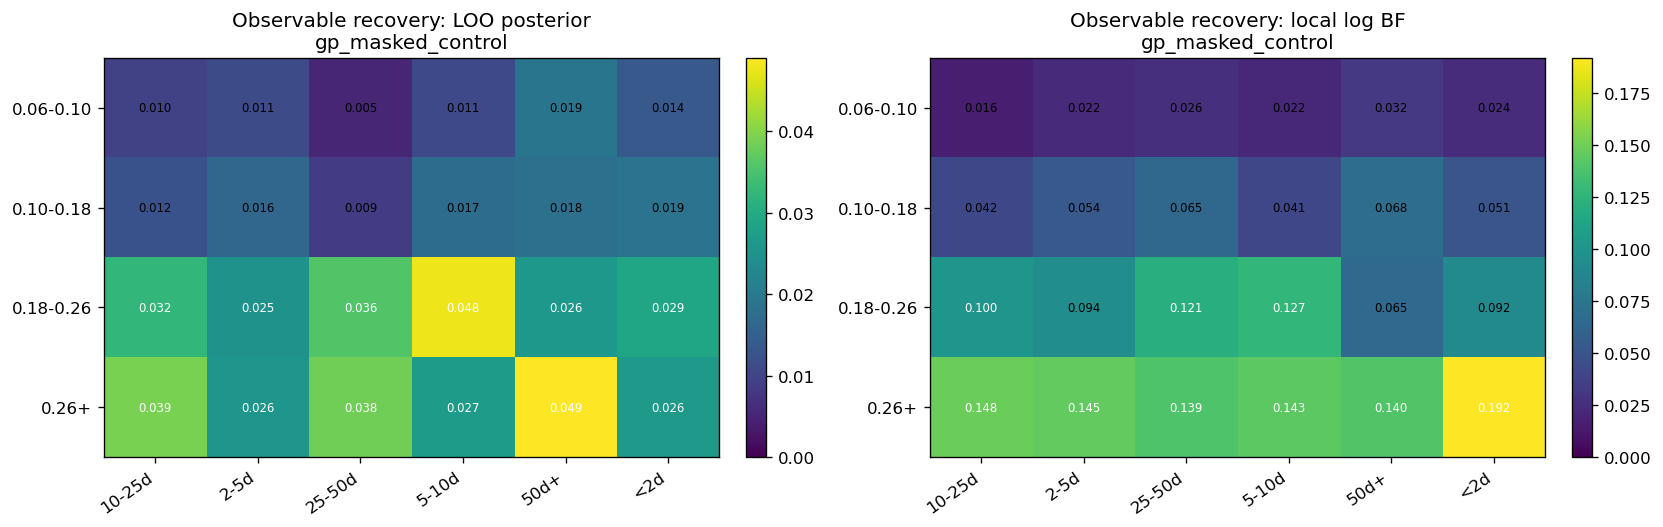

In [10]:
from malca.plotting.lightcurve_publication import finalize_publication_figure
def heatmap_table(df, *, mode, family, metric="target_recovered", row="dip_amp_bin", col="period_bin"):
    sub = df[
        df["status"].eq("ok")
        & df["is_production"].fillna(False).astype(bool)
        & df["mode"].eq(mode)
        & df["trigger_family"].eq(family)
        & df["has_dip"].fillna(False).astype(bool)
        & df["truth_observable_actual"].fillna(False).astype(bool)
    ].copy()
    if sub.empty:
        return pd.DataFrame()
    table = sub.pivot_table(index=row, columns=col, values=metric, aggfunc=lambda x: np.mean(pd.Series(x).fillna(False).astype(bool)))
    return table

def plot_heatmap(table, ax, title):
    if table.empty:
        ax.set_axis_off()
        ax.set_title(title + " (no data)")
        return
    im = ax.imshow(table.to_numpy(dtype=float), aspect="auto", vmin=0, vmax=np.nanmax(table.to_numpy(dtype=float)) if np.nanmax(table.to_numpy(dtype=float)) > 0 else 1)
    ax.set_xticks(np.arange(table.shape[1]), table.columns, rotation=35, ha="right")
    ax.set_yticks(np.arange(table.shape[0]), table.index)
    ax.set_title(title)
    for i in range(table.shape[0]):
        for j in range(table.shape[1]):
            val = table.iloc[i, j]
            if np.isfinite(val):
                ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=7, color="white" if val > 0.5 * np.nanmax(table.to_numpy(dtype=float)) else "black")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

for mode in MODE_NAMES:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    for ax, family in zip(axes, ["loo_posterior_prob", "local_logbf"]):
        table = heatmap_table(results, mode=mode, family=family)
        label = "LOO posterior" if family == "loo_posterior_prob" else "local log BF"
        plot_heatmap(table, ax, f"Observable recovery: {label}\n{mode}")
    finalize_publication_figure(fig)
    fig.savefig(plots_dir / f"recovery_heatmap_{mode}.png")
    plt.show()


## Direct Disagreement Tables

These tables are matched at the trial and baseline-mode level for the two production triggers. They isolate cases where one trigger recovers the injected dip and the other does not, plus control false positives unique to either trigger.


In [11]:
def paired_production_table(df, mode):
    prod = df[df["status"].eq("ok") & df["is_production"].fillna(False).astype(bool) & df["mode"].eq(mode)].copy()
    pp = prod[prod["trigger_family"].eq("loo_posterior_prob")].set_index("trial_id")
    bf = prod[prod["trigger_family"].eq("local_logbf")].set_index("trial_id")
    common = pp.index.intersection(bf.index)
    if common.empty:
        return pd.DataFrame()
    cols = [
        "dip_class", "dip_amp_mag", "dip_sigma_days", "truth_support_points_actual", "truth_peak_snr_actual",
        "period_days", "n_points_actual", "waveform_kind", "max_event_probability", "max_log_bf_local",
        "baseline_mae_outside_dip", "resid_rms_outside_dip",
    ]
    out = pp.loc[common, cols].copy()
    out["posterior_recovered"] = pp.loc[common, "target_recovered"].fillna(False).astype(bool)
    out["logbf_recovered"] = bf.loc[common, "target_recovered"].fillna(False).astype(bool)
    out["posterior_fp"] = pp.loc[common, "false_positive"].fillna(False).astype(bool)
    out["logbf_fp"] = bf.loc[common, "false_positive"].fillna(False).astype(bool)
    out["posterior_event_points"] = pp.loc[common, "event_points"]
    out["logbf_event_points"] = bf.loc[common, "event_points"]
    out["posterior_off_target"] = pp.loc[common, "off_target_detection"].fillna(False).astype(bool)
    out["logbf_off_target"] = bf.loc[common, "off_target_detection"].fillna(False).astype(bool)
    return out.reset_index()

paired_tables = {mode: paired_production_table(results, mode) for mode in MODE_NAMES}

for mode, table in paired_tables.items():
    if table.empty:
        continue
    print(f"\n=== {mode}: posterior-only recovered ===")
    display(table[table["posterior_recovered"] & ~table["logbf_recovered"]].sort_values("max_event_probability", ascending=False).head(20))
    print(f"\n=== {mode}: logBF-only recovered ===")
    display(table[~table["posterior_recovered"] & table["logbf_recovered"]].sort_values("max_log_bf_local", ascending=False).head(20))
    print(f"\n=== {mode}: posterior-only control false positives ===")
    display(table[table["posterior_fp"] & ~table["logbf_fp"]].sort_values("max_event_probability", ascending=False).head(20))
    print(f"\n=== {mode}: logBF-only control false positives ===")
    display(table[~table["posterior_fp"] & table["logbf_fp"]].sort_values("max_log_bf_local", ascending=False).head(20))


/tmp/ipykernel_2684121/2463302023.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  out["posterior_recovered"] = pp.loc[common, "target_recovered"].fillna(False).astype(bool)
/tmp/ipykernel_2684121/2463302023.py:15: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  out["logbf_recovered"] = bf.loc[common, "target_recovered"].fillna(False).astype(bool)
/tmp/ipykernel_2684121/2463302023.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) inst


=== phase_template_true_period: posterior-only recovered ===


/tmp/ipykernel_2684121/2463302023.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  out["posterior_recovered"] = pp.loc[common, "target_recovered"].fillna(False).astype(bool)
/tmp/ipykernel_2684121/2463302023.py:15: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  out["logbf_recovered"] = bf.loc[common, "target_recovered"].fillna(False).astype(bool)
/tmp/ipykernel_2684121/2463302023.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) inst

,trial_id,dip_class,dip_amp_mag,dip_sigma_days,truth_support_points_actual,truth_peak_snr_actual,period_days,n_points_actual,waveform_kind,max_event_probability,max_log_bf_local,baseline_mae_outside_dip,resid_rms_outside_dip,posterior_recovered,logbf_recovered,posterior_fp,logbf_fp,posterior_event_points,logbf_event_points,posterior_off_target,logbf_off_target



=== phase_template_true_period: logBF-only recovered ===


...

,trial_id,dip_class,dip_amp_mag,dip_sigma_days,truth_support_points_actual,truth_peak_snr_actual,period_days,n_points_actual,waveform_kind,max_event_probability,max_log_bf_local,baseline_mae_outside_dip,resid_rms_outside_dip,posterior_recovered,logbf_recovered,posterior_fp,logbf_fp,posterior_event_points,logbf_event_points,posterior_off_target,logbf_off_target
3016,3193,small,0.104943,0.293439,1.0,5.004331,1.093191,138.0,mixed,1.0,1479.107927,0.149507,0.223270,False,True,False,False,0.0,5.0,False,False
9040,9538,broad,0.178377,14.559745,67.0,19.378454,2.932816,378.0,broad_eclipse,1.0,1173.096288,0.186499,0.203611,False,True,False,False,2.0,6.0,True,False
5016,5260,small,0.129563,2.350933,12.0,6.390963,12.510884,362.0,broad_eclipse,1.0,799.777690,0.206014,0.237987,False,True,False,False,5.0,7.0,True,False
1900,2012,medium,0.285811,2.645216,2.0,23.509066,47.778649,257.0,double_wave,1.0,730.619932,0.142198,0.207955,False,True,False,False,6.0,10.0,True,False
7029,7428,broad,0.216397,14.012642,35.0,24.221147,64.165290,545.0,mixed,1.0,710.203551,0.218422,0.305226,False,True,False,False,0.0,5.0,False,False
8993,9486,small,0.112966,1.381083,4.0,8.142510,4.331340,282.0,mixed,1.0,672.737600,0.191046,0.214570,False,True,False,False,14.0,56.0,True,False
11163,11786,medium,0.331302,5.006866,5.0,11.986574,34.572484,220.0,broad_eclipse,1.0,650.864823,0.139473,0.200775,False,True,False,False,0.0,4.0,False,False
8343,8801,small,0.064301,0.905672,1.0,6.086525,10.475288,156.0,mixed,1.0,604.794439,0.074802,0.161891,False,True,False,False,9.0,19.0,True,False
7763,8194,small,0.119882,0.278603,2.0,3.715082,45.967233,265.0,mixed,1.0,597.915032,0.170729,0.261089,False,True,False,False,0.0,8.0,False,False
2532,2688,broad,0.272218,13.017015,18.0,21.109982,4.339444,183.0,mixed,1.0,582.012105,0.111412,0.150646,False,True,False,False,0.0,2.0,False,False



=== gp_masked_control: posterior-only control false positives ===


,trial_id,dip_class,dip_amp_mag,dip_sigma_days,truth_support_points_actual,truth_peak_snr_actual,period_days,n_points_actual,waveform_kind,max_event_probability,max_log_bf_local,baseline_mae_outside_dip,resid_rms_outside_dip,posterior_recovered,logbf_recovered,posterior_fp,logbf_fp,posterior_event_points,logbf_event_points,posterior_off_target,logbf_off_target



=== gp_masked_control: logBF-only control false positives ===


,trial_id,dip_class,dip_amp_mag,dip_sigma_days,truth_support_points_actual,truth_peak_snr_actual,period_days,n_points_actual,waveform_kind,max_event_probability,max_log_bf_local,baseline_mae_outside_dip,resid_rms_outside_dip,posterior_recovered,logbf_recovered,posterior_fp,logbf_fp,posterior_event_points,logbf_event_points,posterior_off_target,logbf_off_target
10718,11312,control_none,0.0,NaN,0.0,0.0,30.769506,395.0,spot_like,1.0,606.471671,0.234661,0.269971,False,False,False,True,0.0,8.0,False,False
1255,1321,control_none,0.0,NaN,0.0,0.0,2.791296,155.0,broad_eclipse,1.0,566.699412,0.209026,0.258828,False,False,False,True,0.0,11.0,False,False
10770,11365,control_none,0.0,NaN,0.0,0.0,2.215470,320.0,mixed,1.0,525.572332,0.222121,0.285210,False,False,False,True,0.0,2.0,False,False
3622,3829,control_none,0.0,NaN,0.0,0.0,5.496436,276.0,mixed,1.0,368.086017,0.169470,0.233523,False,False,False,True,0.0,6.0,False,False
5288,5586,control_none,0.0,NaN,0.0,0.0,1.327539,430.0,mixed,1.0,356.764026,0.103968,0.148130,False,False,False,True,0.0,2.0,False,False
9496,10018,control_none,0.0,NaN,0.0,0.0,2.965862,614.0,spot_like,1.0,315.696086,0.148387,0.257150,False,False,False,True,0.0,2.0,False,False
11237,11861,control_none,0.0,NaN,0.0,0.0,18.909567,240.0,broad_eclipse,1.0,274.243187,0.184558,0.203775,False,False,False,True,0.0,27.0,False,False
881,928,control_none,0.0,NaN,0.0,0.0,70.850170,299.0,broad_eclipse,1.0,272.785258,0.143453,0.183165,False,False,False,True,0.0,2.0,False,False
1010,1067,control_none,0.0,NaN,0.0,0.0,5.852816,240.0,broad_eclipse,1.0,232.588057,0.055436,0.107461,False,False,False,True,0.0,4.0,False,False
6996,7392,control_none,0.0,NaN,0.0,0.0,1.122611,591.0,broad_eclipse,1.0,232.096037,0.076879,0.116106,False,False,False,True,0.0,3.0,False,False


## Off-Target Detections and False Positives

These are detections that pass the trigger and run-gating thresholds but do not overlap the injected dip support. In dip-bearing trials they are off-target detections; in control trials they are false positives. High counts here usually mean the trigger is responding to periodic-template imperfections, camera offsets, seasonal gaps, or isolated noisy points rather than the injected one-off event.


In [12]:
for family in ["loo_posterior_prob", "local_logbf"]:
    label = "LOO posterior" if family == "loo_posterior_prob" else "local log BF"
    sub = production[production["trigger_family"].eq(family)].copy()
    print(f"\n=== {label}: largest off-target detections ===")
    display(
        sub[sub["off_target_detection"].fillna(False)]
        .sort_values(["max_log_bf_local", "max_event_probability"], ascending=False)
        .head(30)[[
            "trial_id", "mode", "dip_class", "dip_amp_mag", "truth_support_points_actual", "truth_peak_snr_actual",
            "period_days", "n_points_actual", "waveform_kind", "max_event_probability", "max_log_bf_local",
            "event_points", "raw_trigger_points", "baseline_mae_outside_dip", "resid_rms_outside_dip",
        ]]
    )
    print(f"\n=== {label}: largest control false positives ===")
    display(
        sub[sub["false_positive"].fillna(False)]
        .sort_values(["max_log_bf_local", "max_event_probability"], ascending=False)
        .head(30)[[
            "trial_id", "mode", "period_days", "n_points_actual", "waveform_kind", "max_event_probability", "max_log_bf_local",
            "event_points", "raw_trigger_points", "baseline_mae_outside_dip", "resid_rms_outside_dip",
        ]]
    )



=== LOO posterior: largest off-target detections ===


/tmp/ipykernel_2684121/1774423424.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sub[sub["off_target_detection"].fillna(False)]


,trial_id,mode,dip_class,dip_amp_mag,truth_support_points_actual,truth_peak_snr_actual,period_days,n_points_actual,waveform_kind,max_event_probability,max_log_bf_local,event_points,raw_trigger_points,baseline_mae_outside_dip,resid_rms_outside_dip
692262,10816,gp_masked_control,small,0.101245,1.0,6.831165,9.151188,175.0,double_wave,1.0,2178.844094,2.0,5.0,0.182559,0.217769
243254,3799,gp_masked_control,medium,0.268832,4.0,18.950641,63.480278,441.0,mixed,1.0,1800.979348,2.0,7.0,0.225808,0.326427
352470,5506,gp_masked_control,broad,0.198752,5.0,15.464333,1.283768,184.0,broad_eclipse,1.0,1747.046434,4.0,11.0,0.191401,0.240304
187382,2926,gp_masked_control,medium,0.312888,7.0,26.560551,62.279250,499.0,mixed,1.0,1641.258413,4.0,7.0,0.195514,0.223223
120614,1880,gp_masked_control,small,0.062079,2.0,10.712956,64.044098,115.0,double_wave,1.0,1551.777001,10.0,13.0,0.149979,0.211773
384454,6002,gp_masked_control,small,0.119954,4.0,9.603600,65.999493,310.0,broad_eclipse,1.0,1237.170353,2.0,5.0,0.199767,0.231255
78870,1231,gp_masked_control,medium,0.175375,2.0,14.957464,18.315874,261.0,mixed,1.0,1195.066637,2.0,6.0,0.204233,0.222336
26630,410,gp_masked_control,small,0.119813,1.0,8.357467,2.458578,139.0,broad_eclipse,1.0,1181.029456,15.0,20.0,0.246920,0.256320
610502,9538,gp_masked_control,broad,0.178377,67.0,19.378454,2.932816,378.0,broad_eclipse,1.0,1173.096288,2.0,6.0,0.186499,0.203611
4534,67,gp_masked_control,medium,0.203620,24.0,17.107669,18.247426,351.0,sinusoid,1.0,1121.156168,4.0,13.0,0.236523,0.259072



=== LOO posterior: largest control false positives ===


/tmp/ipykernel_2684121/1774423424.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sub[sub["false_positive"].fillna(False)]


...

/tmp/ipykernel_2684121/1774423424.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sub[sub["off_target_detection"].fillna(False)]


,trial_id,mode,dip_class,dip_amp_mag,truth_support_points_actual,truth_peak_snr_actual,period_days,n_points_actual,waveform_kind,max_event_probability,max_log_bf_local,event_points,raw_trigger_points,baseline_mae_outside_dip,resid_rms_outside_dip
692267,10816,gp_masked_control,small,0.101245,1.0,6.831165,9.151188,175.0,double_wave,1.0,2178.844094,5.0,9.0,0.182559,0.217769
288123,4501,gp_masked_control,small,0.117982,1.0,6.518046,1.156481,122.0,broad_eclipse,1.0,1974.896850,4.0,6.0,0.280784,0.337766
243259,3799,gp_masked_control,medium,0.268832,4.0,18.950641,63.480278,441.0,mixed,1.0,1800.979348,11.0,16.0,0.225808,0.326427
352475,5506,gp_masked_control,broad,0.198752,5.0,15.464333,1.283768,184.0,broad_eclipse,1.0,1747.046434,8.0,14.0,0.191401,0.240304
187387,2926,gp_masked_control,medium,0.312888,7.0,26.560551,62.279250,499.0,mixed,1.0,1641.258413,6.0,9.0,0.195514,0.223223
120619,1880,gp_masked_control,small,0.062079,2.0,10.712956,64.044098,115.0,double_wave,1.0,1551.777001,19.0,22.0,0.149979,0.211773
460891,7201,gp_masked_control,medium,0.172648,4.0,10.705050,52.258104,173.0,double_wave,1.0,1392.848632,12.0,14.0,0.185579,0.286145
384459,6002,gp_masked_control,small,0.119954,4.0,9.603600,65.999493,310.0,broad_eclipse,1.0,1237.170353,10.0,16.0,0.199767,0.231255
78875,1231,gp_masked_control,medium,0.175375,2.0,14.957464,18.315874,261.0,mixed,1.0,1195.066637,4.0,8.0,0.204233,0.222336
26635,410,gp_masked_control,small,0.119813,1.0,8.357467,2.458578,139.0,broad_eclipse,1.0,1181.029456,18.0,22.0,0.246920,0.256320



=== local log BF: largest control false positives ===


/tmp/ipykernel_2684121/1774423424.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sub[sub["false_positive"].fillna(False)]


,trial_id,mode,period_days,n_points_actual,waveform_kind,max_event_probability,max_log_bf_local,event_points,raw_trigger_points,baseline_mae_outside_dip,resid_rms_outside_dip
715259,11175,gp_masked_control,18.177816,115.0,mixed,1.0,798.116288,2.0,5.0,0.127626,0.202149
422795,6603,gp_masked_control,0.888918,316.0,sinusoid,1.0,789.388908,2.0,8.0,0.234452,0.294398
420299,6566,gp_masked_control,74.089268,355.0,sinusoid,1.0,739.922799,5.0,8.0,0.149197,0.178483
720923,11264,gp_masked_control,2.353805,266.0,sinusoid,1.0,722.589328,2.0,5.0,0.147615,0.202050
327867,5121,gp_masked_control,9.951446,315.0,mixed,1.0,611.855100,4.0,8.0,0.173719,0.211232
724219,11312,gp_masked_control,30.769506,395.0,spot_like,1.0,606.471671,8.0,14.0,0.234661,0.269971
495387,7739,gp_masked_control,1.562082,178.0,double_wave,1.0,596.538057,11.0,14.0,0.193583,0.267401
84667,1321,gp_masked_control,2.791296,155.0,broad_eclipse,1.0,566.699412,11.0,12.0,0.209026,0.258828
688939,10762,gp_masked_control,36.221974,179.0,mixed,1.0,548.746860,6.0,8.0,0.187079,0.264924
727611,11365,gp_masked_control,2.215470,320.0,mixed,1.0,525.572332,2.0,7.0,0.222121,0.285210


## Diagnostic Example Plots

For the selected mode, the notebook picks representative production-trigger disagreements and recomputes the simulated light curve. The plots overlay truth support, posterior-triggered points, logBF-triggered points, per-point LOO probability, per-point log BF, and the folded baseline.


/home/calder/code/malca/malca/evaluation/trigger_mode_simulation_benchmark.py:926: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  pp_rec = pp["target_recovered"].fillna(False).astype(bool)
/home/calder/code/malca/malca/evaluation/trigger_mode_simulation_benchmark.py:927: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  bf_rec = bf["target_recovered"].fillna(False).astype(bool)
/home/calder/code/malca/malca/evaluation/trigger_mode_simulation_benchmark.py:928: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will chan

phase_template_true_period
{'both_recovered': 9822, 'posterior_only_recovered': None, 'logbf_only_recovered': 8784, 'posterior_only_false_positive': None, 'logbf_only_false_positive': 8910, 'both_false_positive': 3576}


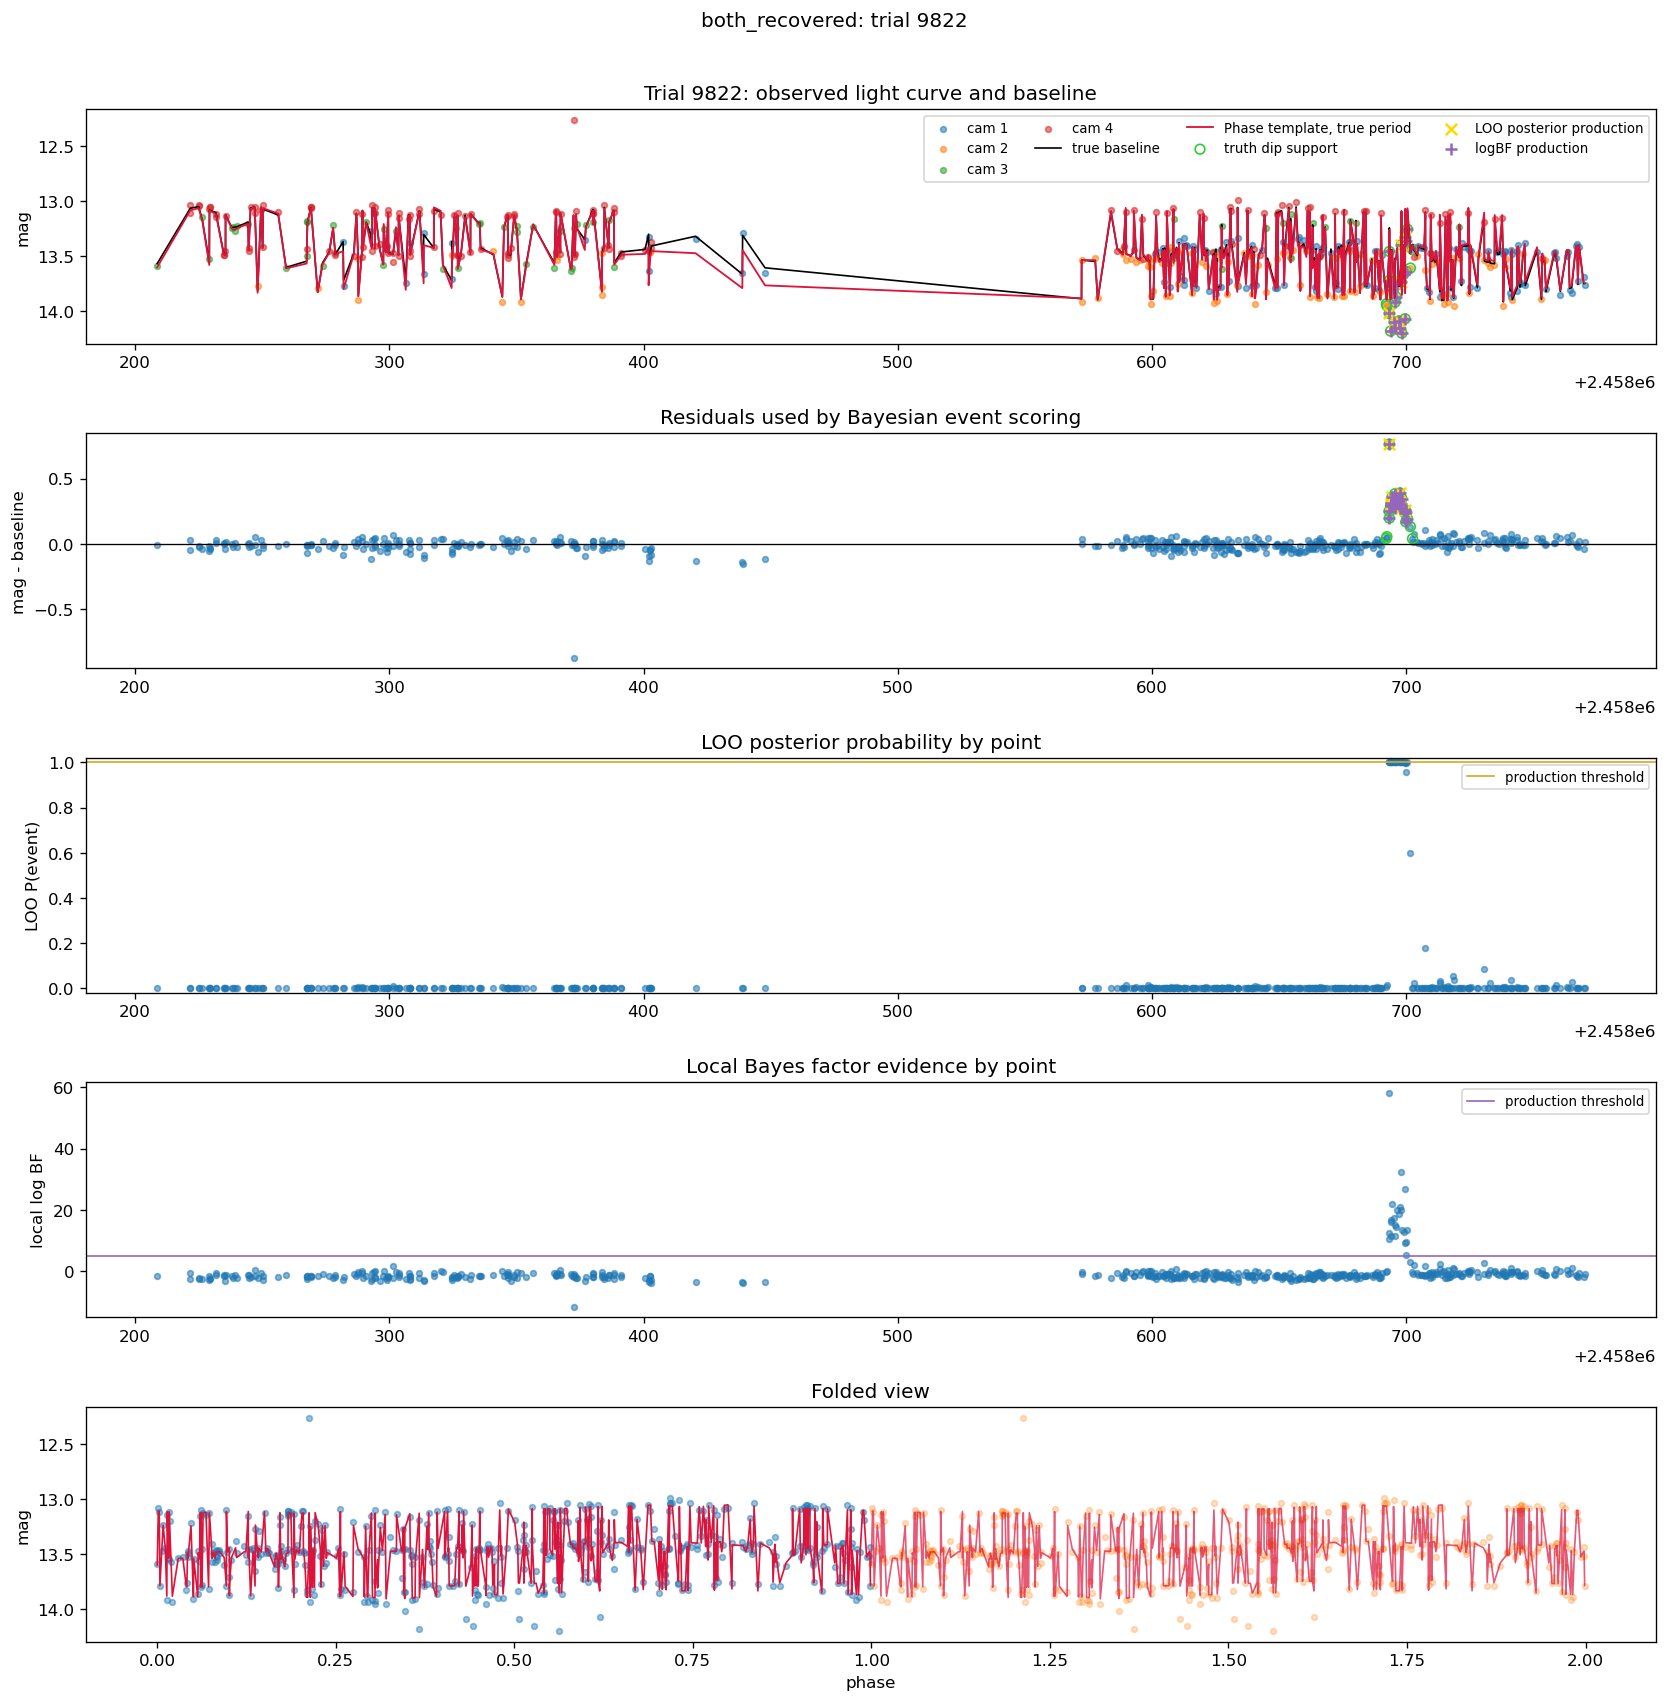

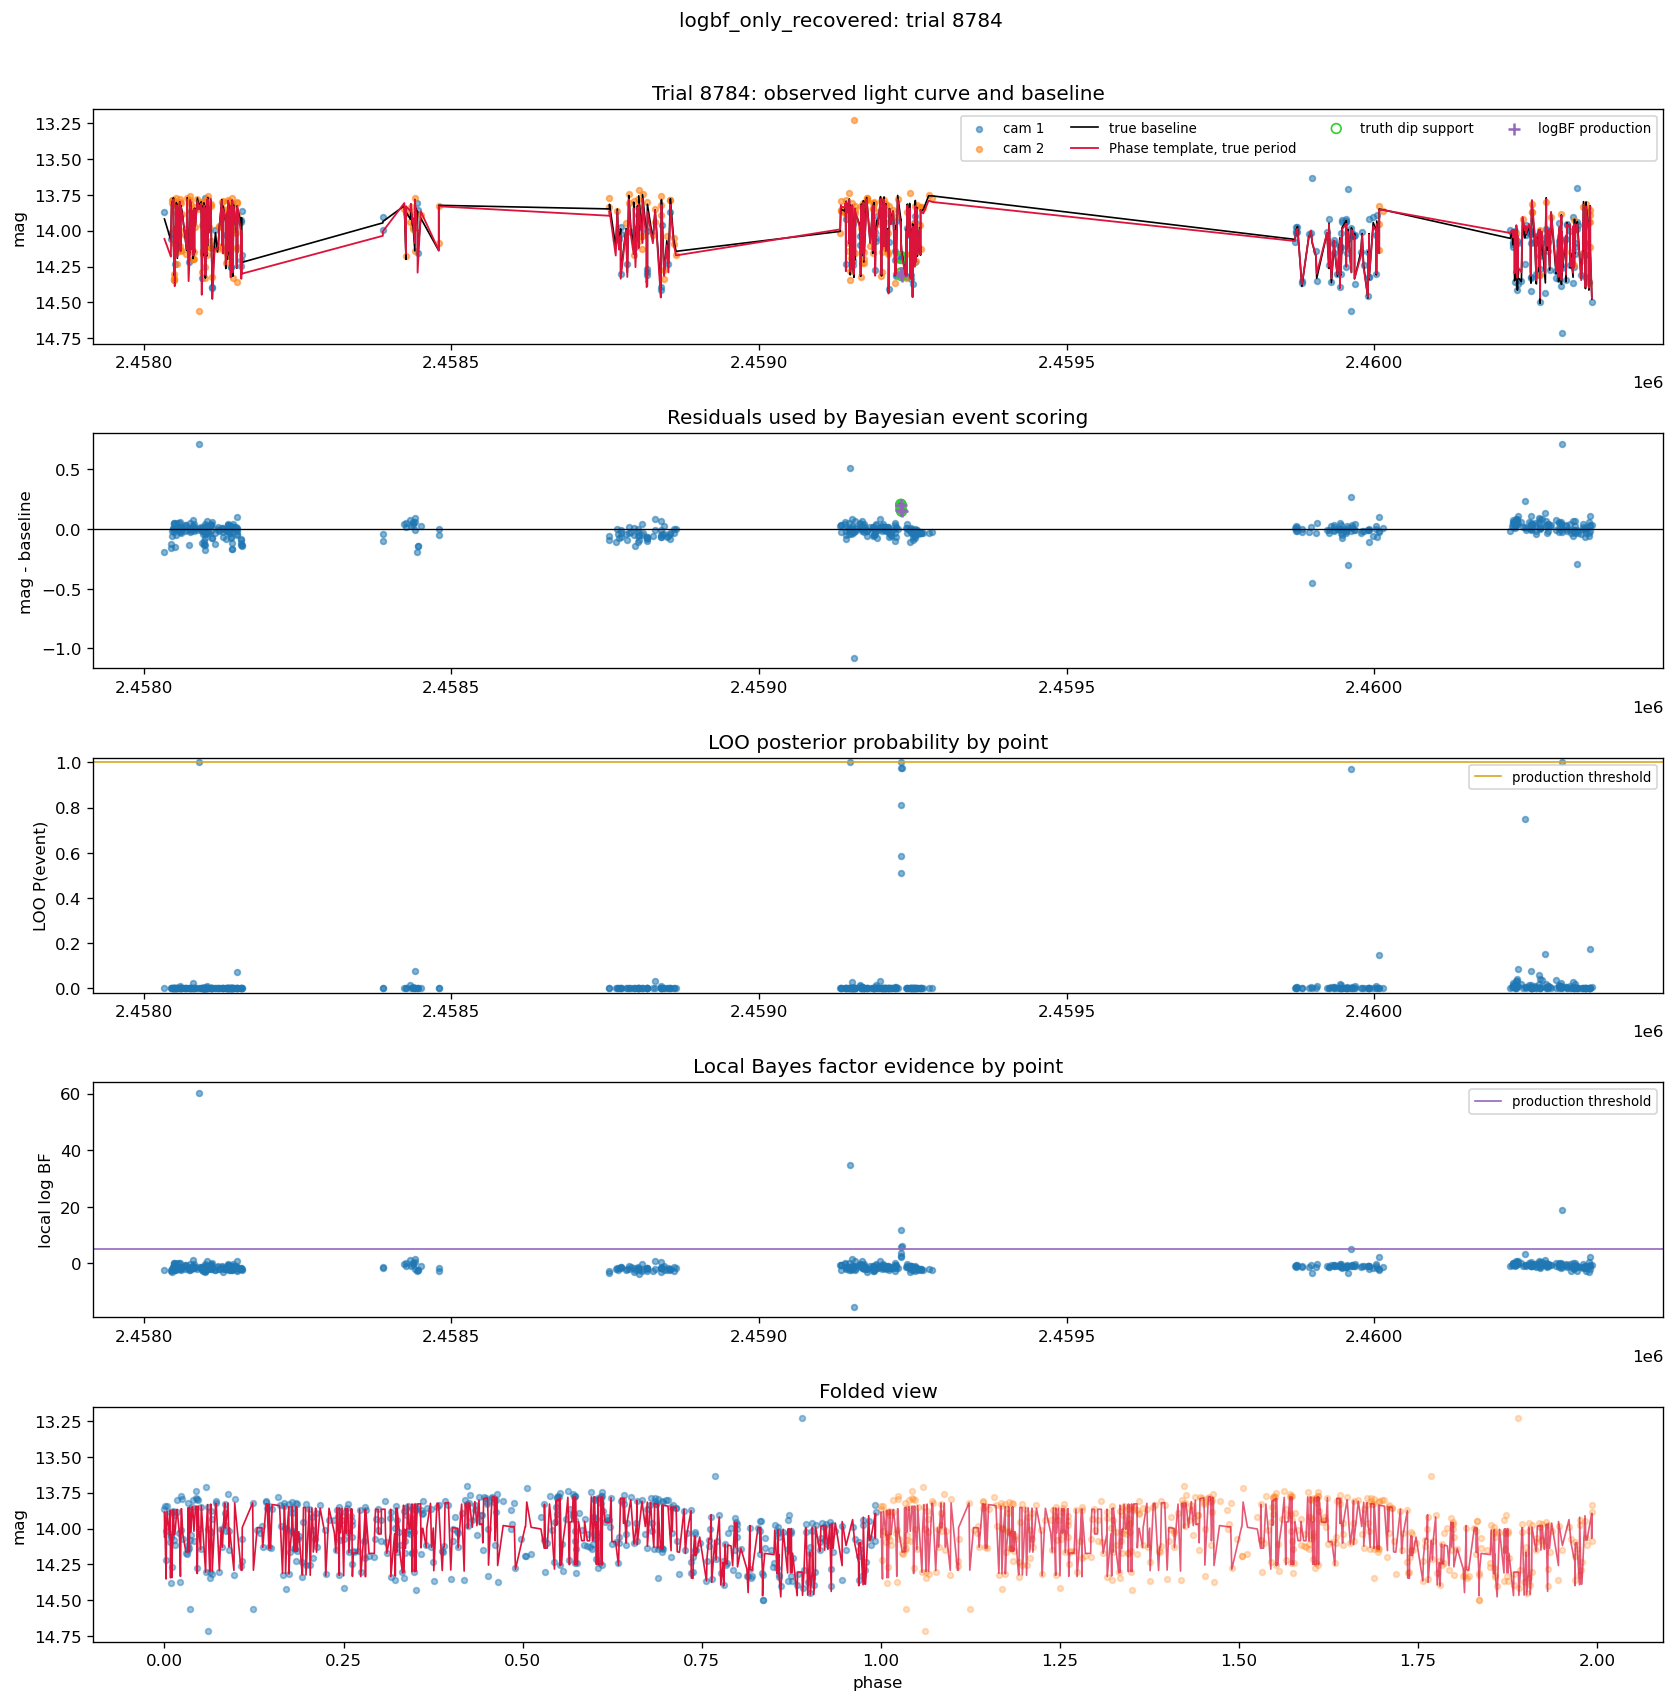

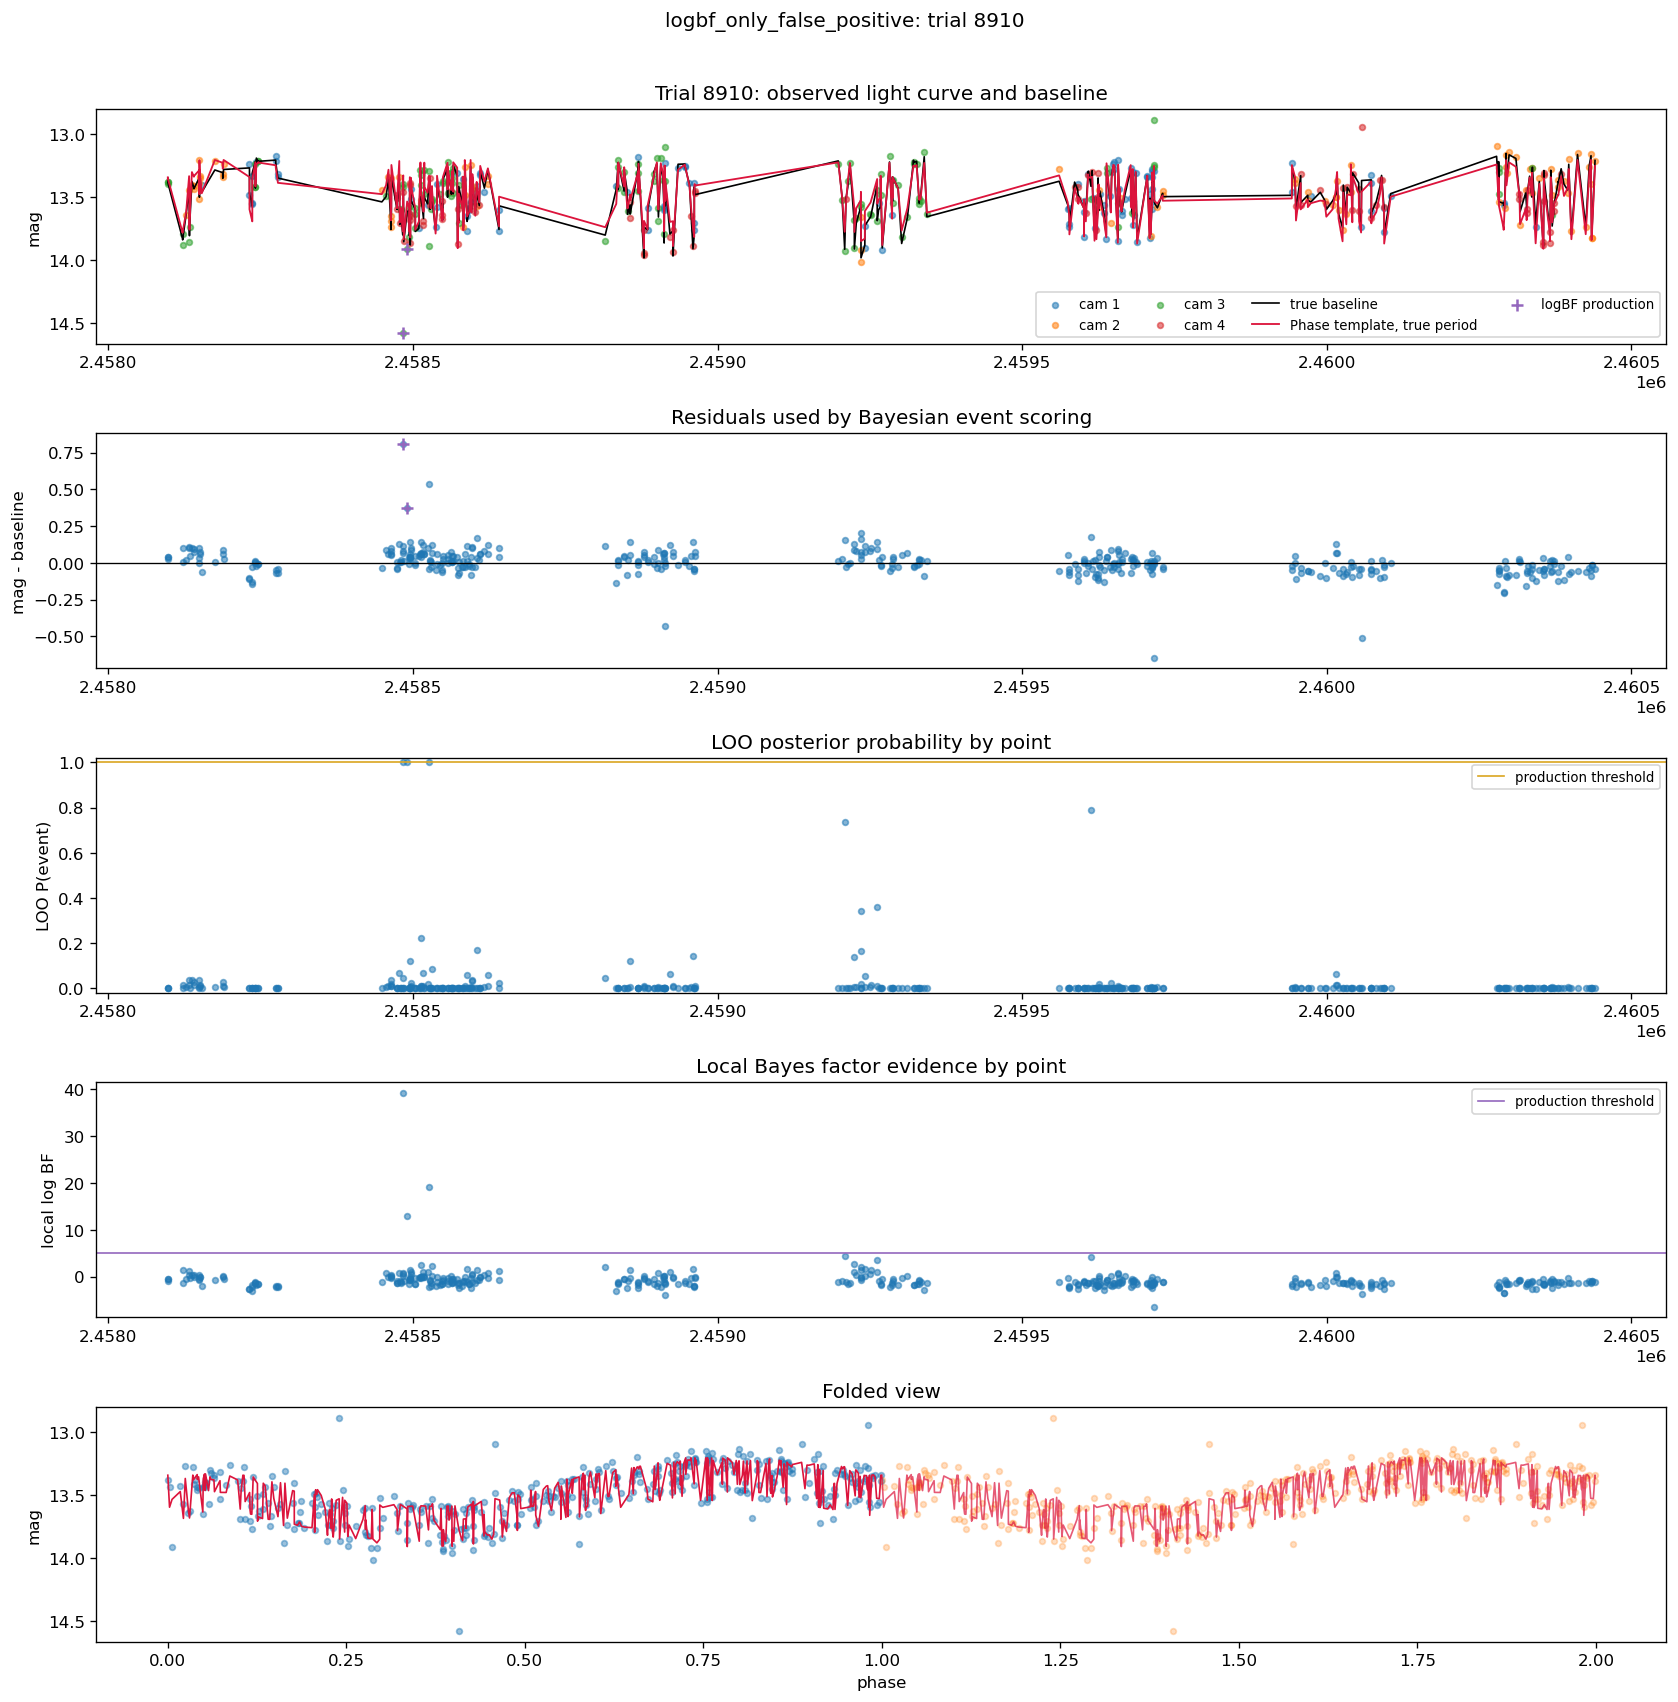

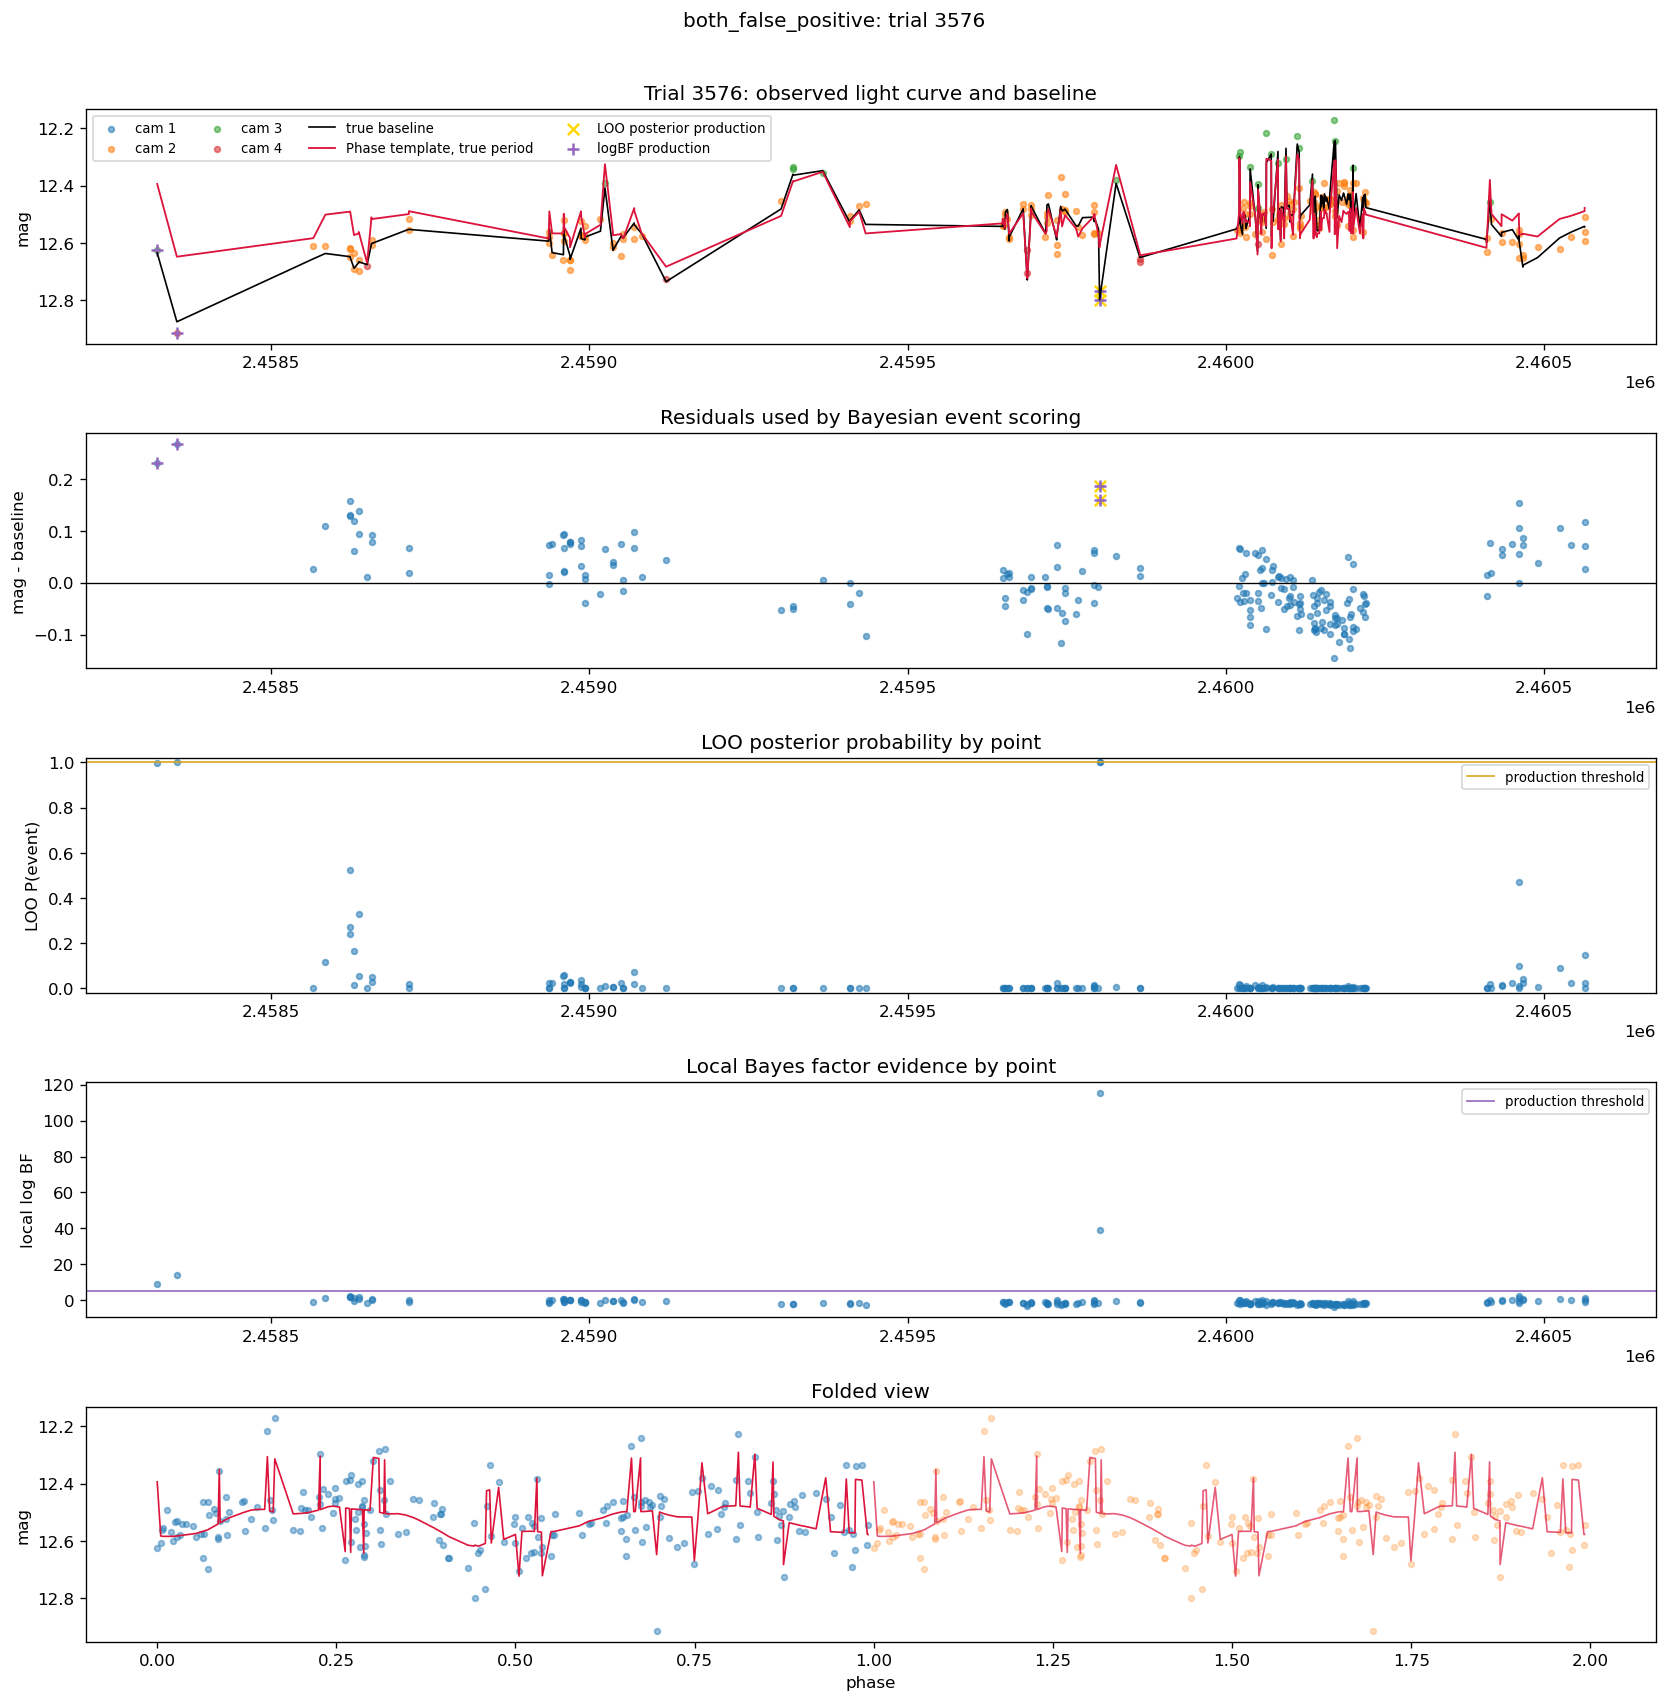

In [13]:
from malca.plotting.lightcurve_publication import finalize_publication_figure
EXAMPLE_MODE = os.environ.get("MALCA_TRIGGER_MODE_EXAMPLE_MODE", "phase_template_true_period")
examples = select_disagreement_trials(results, mode=EXAMPLE_MODE)
print(EXAMPLE_MODE)
print(examples)

for label, trial_id in examples.items():
    if trial_id is None:
        continue
    fig, axes = plt.subplots(5, 1, figsize=(14, 14), sharex=False)
    plot_trigger_mode_trial_diagnostic(run, int(trial_id), mode=EXAMPLE_MODE, ax=axes)
    fig.suptitle(f"{label}: trial {trial_id}", y=1.01)
    finalize_publication_figure(fig)
    fig.savefig(plots_dir / f"diagnostic_{EXAMPLE_MODE}_{label}_trial_{trial_id}.png")
    plt.show()


## Quick Interpretation Checklist

Use this notebook in this order:

1. Check the simulation audit to make sure the synthetic population is broad enough for the question being asked.
2. Read `production_overall` and `pairwise_production` first. This is the current operational LOO-vs-BF comparison.
3. Use threshold sweeps to decide whether a trigger family is fundamentally weak or merely poorly thresholded.
4. Use slice tables and recovery heatmaps to identify the regimes where the trigger fails: low amplitude, sparse sampling, long/short periods, broad dips, or waveform-specific baseline mismatch.
5. Inspect disagreement plots. The top panels tell you whether the baseline is wrong; the posterior and logBF panels tell you whether the trigger family is suppressing or amplifying the same residual excursions.

The most actionable patterns are:

- **High logBF-only recovery with many logBF false positives**: local evidence is sensitive but needs stricter run/morphology gating or a higher threshold.
- **Posterior-only recovery with low false positives**: LOO probability is finding coherent event support that local logBF thresholding misses.
- **Both triggers miss high-SNR observable dips**: the bottleneck is probably baseline construction, run gating, injected event support definition, or the event-grid parameterization rather than trigger mode.
- **Both triggers fire off target**: baseline residual structure is being scored as a dip; inspect camera offsets, phase-template period errors, and seasonal gaps.
